# ⚽ UEFA Champions League Match Predictor
## End-to-End Machine Learning Project
### Predicting: **Arsenal vs PSG** — UCL Final

---

**Author:** Senior Data Scientist / ML Engineer  
**Objective:** Build a production-grade ML pipeline that estimates win probabilities for a UCL match based on historical team performance, form, and advanced football statistics.

> ⚠️ **Disclaimer:** This model does NOT predict the future. It estimates probabilities based on historical data and statistical patterns. Football is inherently unpredictable.

---

## 📋 Project Architecture

```
┌─────────────────────────────────────────────────────────────┐
│                    ML PIPELINE OVERVIEW                     │
├─────────────────┬──────────────────┬───────────────────────┤
│  1. Data Layer  │  2. Feature Eng. │  3. Model Training    │
│                 │                  │                        │
│  • soccerway    │  • Team Form     │  • Logistic Reg.      │
│  • FBref style  │  • Elo Ratings   │  • Random Forest      │
│  • Elo ratings  │  • Attack/Def    │  • XGBoost            │
│  • Historical   │  • UCL Perf.     │  • Ensemble           │
│    match data   │  • Head-to-Head  │                        │
├─────────────────┴──────────────────┴───────────────────────┤
│  4. Evaluation → 5. Prediction → 6. Visualization          │
└─────────────────────────────────────────────────────────────┘
```

## 🔧 Section 1: Environment Setup & Library Installation

In [1]:
# ============================================================
# CELL 1: Install Dependencies
# ============================================================
!pip install xgboost lightgbm shap optuna scikit-learn pandas numpy \
             matplotlib seaborn plotly requests beautifulsoup4 \
             imbalanced-learn yellowbrick --quiet

print("✅ All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.7 MB/s eta 0:00:00
✅ All libraries installed successfully!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
import json
import re
from datetime import datetime, timedelta
from collections import defaultdict

# ML Libraries
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, log_loss, brier_score_loss, roc_curve,
    precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
import lightgbm as lgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
np.random.seed(42)

# Plotting config
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#e6edf3',
    'grid.color': '#21262d',
    'grid.alpha': 0.5,
    'font.family': 'monospace'
})

print("✅ Libraries loaded successfully!")
print(f"📅 Run Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Libraries loaded successfully!
📅 Run Date: 2026-05-27 14:24:59


---
## 📊 Section 2: Dataset Construction

We build a realistic historical match dataset encoding:
- **Champions League matches** from 2015–2024 (9 seasons)
- **Team-level aggregated statistics** (Elo, form, attack/defense strength)
- **Head-to-head records**
- **UCL-specific performance** (knockout round history)

> 💡 **Real-world data sources you can plug in:**
> - [football-data.co.uk](https://www.football-data.co.uk/) — free CSV downloads
> - [club-elo.com](http://clubelo.com/) — historical Elo ratings API
> - [FBref.com](https://fbref.com/) — advanced stats (xG, progressive passes)
> - [Kaggle: European Football Database](https://www.kaggle.com/datasets/peshimasean/european-football-dataset)

In [5]:
# ============================================================
# CELL 3: Define UCL Historical Data (2015-2024)
# ============================================================

# ─── Team Elo Ratings (approximate historical averages) ──────
# Source methodology: clubelo.com rating system (1500 = average top club)
TEAM_ELO = {
    'Real Madrid':      1955, 'Manchester City':   1940, 'Bayern Munich':     1995,
    'Barcelona':        1980, 'Liverpool':         1935, 'PSG':               1950,
    'Arsenal':          2060, 'Chelsea':           1885, 'Atletico Madrid':   1875,
    'Juventus':         1830, 'Borussia Dortmund': 1860, 'Inter Milan':       1890,
    'Porto':            1710, 'Ajax':              1750, 'Benfica':           1695,
    'Napoli':           1725, 'AC Milan':          1760, 'Sevilla':           1660,
    'RB Leipzig':       1700, 'Tottenham':         1770, 'Villarreal':        1650,
    'Monaco':           1730, 'Roma':              1680, 'Shakhtar Donetsk':  1600,
}

# ─── UCL Historical Statistics per team ──────────────────────
UCL_STATS = {
    # Format: {wins, draws, losses, goals_for, goals_against,
    #          ucl_seasons, ucl_titles, finals_reached}
    'Real Madrid':      {'ucl_seasons':11, 'ucl_titles':5, 'finals':5, 'ucl_wins':96, 'ucl_draws':20, 'ucl_losses':14, 'ucl_gf':289, 'ucl_ga':120},

    'Manchester City':  {'ucl_seasons':11, 'ucl_titles':1, 'finals':2, 'ucl_wins':76, 'ucl_draws':18, 'ucl_losses':14, 'ucl_gf':265, 'ucl_ga':98},

    'Bayern Munich':    {'ucl_seasons':11, 'ucl_titles':1, 'finals':1, 'ucl_wins':79, 'ucl_draws':13, 'ucl_losses':16, 'ucl_gf':286, 'ucl_ga':112},

    'PSG':              {'ucl_seasons':11, 'ucl_titles':1, 'finals':2, 'ucl_wins':69, 'ucl_draws':16, 'ucl_losses':25, 'ucl_gf':238, 'ucl_ga':128},

    'Arsenal':          {'ucl_seasons':5, 'ucl_titles':0, 'finals':1, 'ucl_wins':23, 'ucl_draws':8,  'ucl_losses':15, 'ucl_gf':78,  'ucl_ga':60},

    'Barcelona':        {'ucl_seasons':11, 'ucl_titles':1, 'finals':1, 'ucl_wins':71, 'ucl_draws':16, 'ucl_losses':23, 'ucl_gf':248, 'ucl_ga':132},

    'Liverpool':        {'ucl_seasons':10, 'ucl_titles':1, 'finals':3, 'ucl_wins':73, 'ucl_draws':15, 'ucl_losses':20, 'ucl_gf':245, 'ucl_ga':108},

    'Chelsea':          {'ucl_seasons':10, 'ucl_titles':1, 'finals':1, 'ucl_wins':58, 'ucl_draws':22, 'ucl_losses':20, 'ucl_gf':190, 'ucl_ga':98},

    'Atletico Madrid':  {'ucl_seasons':11, 'ucl_titles':0, 'finals':2, 'ucl_wins':58, 'ucl_draws':24, 'ucl_losses':22, 'ucl_gf':160, 'ucl_ga':96},

    'Juventus':         {'ucl_seasons':11, 'ucl_titles':0, 'finals':2, 'ucl_wins':52, 'ucl_draws':22, 'ucl_losses':24, 'ucl_gf':152, 'ucl_ga':102},

    'Borussia Dortmund':{'ucl_seasons':10, 'ucl_titles':0, 'finals':1, 'ucl_wins':48, 'ucl_draws':16, 'ucl_losses':22, 'ucl_gf':162, 'ucl_ga':115},

    'Inter Milan':      {'ucl_seasons':9, 'ucl_titles':0, 'finals':2, 'ucl_wins':44, 'ucl_draws':18, 'ucl_losses':18, 'ucl_gf':145, 'ucl_ga':88},

    'Porto':            {'ucl_seasons':9, 'ucl_titles':0, 'finals':0, 'ucl_wins':38, 'ucl_draws':14, 'ucl_losses':24, 'ucl_gf':120, 'ucl_ga':96},

    'Ajax':             {'ucl_seasons':7, 'ucl_titles':0, 'finals':0, 'ucl_wins':34, 'ucl_draws':11, 'ucl_losses':17, 'ucl_gf':122, 'ucl_ga':84},

    'Napoli':           {'ucl_seasons':7, 'ucl_titles':0, 'finals':0, 'ucl_wins':31, 'ucl_draws':13, 'ucl_losses':14, 'ucl_gf':108, 'ucl_ga':70},

    'AC Milan':         {'ucl_seasons':8, 'ucl_titles':0, 'finals':0, 'ucl_wins':39, 'ucl_draws':15, 'ucl_losses':16, 'ucl_gf':122, 'ucl_ga':82},
}

print(f"✅ Team database loaded: {len(TEAM_ELO)} teams with Elo ratings")
print(f"📊 UCL stats available for: {len(UCL_STATS)} teams")

✅ Team database loaded: 24 teams with Elo ratings
📊 UCL stats available for: 16 teams


In [6]:
# ============================================================
# CELL 4: Simulate Realistic Historical Match Dataset
# ============================================================
# This function generates statistically calibrated synthetic match data
# that mirrors real UCL match distributions.
# Replace with real data by loading CSV/API in the next cell.

def generate_ucl_match_dataset(n_seasons=9, seed=42):
    """Generate a realistic historical UCL match dataset."""
    np.random.seed(seed)

    teams = list(UCL_STATS.keys())
    records = []

    for season_idx in range(n_seasons):
        season_year = 2015 + season_idx
        season = f"{season_year}/{str(season_year+1)[-2:]}"

        # Group stage: 32 teams in 8 groups
        np.random.shuffle(teams)
        groups = [teams[i:i+4] for i in range(0, min(32, len(teams)), 4)]

        for group_idx, group in enumerate(groups):
            for i, home_team in enumerate(group):
                for j, away_team in enumerate(group):
                    if i == j:
                        continue
                    record = _simulate_match(
                        home_team, away_team, season,
                        f"Group {chr(65+group_idx)}", season_idx
                    )
                    records.append(record)

        # Knockout stages
        ko_teams = teams[:16]
        for stage in ['Round of 16', 'Quarter-Finals', 'Semi-Finals', 'Final']:
            if len(ko_teams) < 2:
                break
            np.random.shuffle(ko_teams)
            next_round = []
            for k in range(0, len(ko_teams)-1, 2):
                home_team = ko_teams[k]
                away_team = ko_teams[k+1]
                # First leg
                record = _simulate_match(
                    home_team, away_team, season, stage + ' - Leg 1', season_idx
                )
                records.append(record)
                # Second leg (reversed)
                record = _simulate_match(
                    away_team, home_team, season, stage + ' - Leg 2', season_idx
                )
                records.append(record)
                # Winner advances (simplified)
                home_elo = TEAM_ELO.get(home_team, 1700)
                away_elo = TEAM_ELO.get(away_team, 1700)
                prob = 1 / (1 + 10 ** ((away_elo - home_elo) / 400))
                winner = home_team if np.random.random() < prob else away_team
                next_round.append(winner)
            ko_teams = next_round

    return pd.DataFrame(records)


def _simulate_match(home_team, away_team, season, stage, season_idx):
    """Simulate a single match using Elo-based probabilities."""
    home_elo = TEAM_ELO.get(home_team, 1700)
    away_elo = TEAM_ELO.get(away_team, 1700)

    # Home advantage: ~60 Elo points
    home_advantage = 60 if 'Final' not in stage else 0  # neutral venue for finals

    # Expected win probability (Elo formula)
    elo_diff = (home_elo + home_advantage) - away_elo
    home_win_prob = 1 / (1 + 10 ** (-elo_diff / 400))

    # Adjust for draw probability (typical in football: ~25-28%)
    draw_prob = 0.27 - abs(elo_diff) * 0.0003
    draw_prob = max(0.10, min(draw_prob, 0.32))
    home_win_prob = home_win_prob * (1 - draw_prob)
    away_win_prob = (1 - draw_prob) - home_win_prob

    # Sample outcome
    rand = np.random.random()
    if rand < home_win_prob:
        result = 'H'
    elif rand < home_win_prob + draw_prob:
        result = 'D'
    else:
        result = 'A'

    # Generate realistic scorelines
    home_attack = (home_elo - 1600) / 200 + 1.2
    away_attack = (away_elo - 1600) / 200 + 0.9

    home_goals = np.random.poisson(max(0.3, home_attack + (0.3 if result == 'H' else -0.3)))
    away_goals = np.random.poisson(max(0.3, away_attack + (0.3 if result == 'A' else -0.3)))

    if result == 'D':
        away_goals = home_goals
    elif result == 'H' and home_goals <= away_goals:
        home_goals = away_goals + np.random.randint(1, 3)
    elif result == 'A' and away_goals <= home_goals:
        away_goals = home_goals + np.random.randint(1, 3)

    # Advanced stats (xG-style)
    home_xg = home_goals * 0.85 + np.random.normal(0.2, 0.3)
    away_xg = away_goals * 0.85 + np.random.normal(0.1, 0.3)
    home_xg = max(0.1, home_xg)
    away_xg = max(0.1, away_xg)

    home_shots = int(home_goals * 4.5 + np.random.poisson(6))
    away_shots = int(away_goals * 4.5 + np.random.poisson(5))
    home_shots_ot = max(home_goals, int(home_shots * np.random.uniform(0.3, 0.5)))
    away_shots_ot = max(away_goals, int(away_shots * np.random.uniform(0.25, 0.45)))

    home_poss = round(np.random.normal(52 + elo_diff * 0.01, 7), 1)
    home_poss = max(30, min(70, home_poss))
    away_poss = round(100 - home_poss, 1)

    return {
        'season': season,
        'stage': stage,
        'home_team': home_team,
        'away_team': away_team,
        'home_goals': int(home_goals),
        'away_goals': int(away_goals),
        'result': result,  # H=home win, D=draw, A=away win
        'home_elo': home_elo,
        'away_elo': away_elo,
        'home_xg': round(home_xg, 2),
        'away_xg': round(away_xg, 2),
        'home_shots': home_shots,
        'away_shots': away_shots,
        'home_shots_on_target': home_shots_ot,
        'away_shots_on_target': away_shots_ot,
        'home_possession': home_poss,
        'away_possession': away_poss,
        'home_corners': int(np.random.poisson(6)),
        'away_corners': int(np.random.poisson(5)),
        'home_fouls': int(np.random.poisson(11)),
        'away_fouls': int(np.random.poisson(12)),
        'is_knockout': 1 if stage not in ['Group A','Group B','Group C','Group D',
                                           'Group E','Group F','Group G','Group H'] and 'Group' not in stage else 0,
        'is_final': 1 if stage == 'Final' else 0,
        'season_idx': season_idx,
    }


# Generate the dataset
df_raw = generate_ucl_match_dataset(n_seasons=9)
print(f"✅ Dataset generated: {df_raw.shape[0]} matches across {df_raw['season'].nunique()} seasons")
print(f"\n📊 Result Distribution:")
print(df_raw['result'].value_counts().to_string())
print(f"\n📋 Sample matches:")
df_raw.head(5)

✅ Dataset generated: 702 matches across 9 seasons

📊 Result Distribution:
result
H    294
A    238
D    170

📋 Sample matches:


,season,stage,home_team,away_team,home_goals,away_goals,result,home_elo,away_elo,home_xg,...,away_shots_on_target,home_possession,away_possession,home_corners,away_corners,home_fouls,away_fouls,is_knockout,is_final,season_idx
0,2015/16,Group A,Real Madrid,Manchester City,4,3,H,1955,1940,3.84,...,7,48.5,51.5,4,6,5,4,0,0,0
1,2015/16,Group A,Real Madrid,Barcelona,3,1,H,1955,1980,2.66,...,3,58.6,41.4,9,2,9,17,0,0,0
2,2015/16,Group A,Real Madrid,Napoli,2,0,H,1955,1725,2.05,...,1,52.1,47.9,9,2,12,4,0,0,0
3,2015/16,Group A,Manchester City,Real Madrid,1,5,A,1940,1955,0.96,...,7,62.1,37.9,6,7,8,13,0,0,0
4,2015/16,Group A,Manchester City,Barcelona,5,3,H,1940,1980,4.54,...,7,55.2,44.8,4,8,13,11,0,0,0


In [ ]:
# ============================================================
# CELL 5: (OPTIONAL) Load Real Data from CSV
# ============================================================
# Uncomment and use any of the following to load real data:

# --- Option A: Upload from Google Drive ---
# from google.colab import drive
# drive.mount('/content/drive')
# df_raw = pd.read_csv('/content/drive/MyDrive/ucl_matches.csv')

# --- Option B: Download from football-data.co.uk ---
# import requests, io
# url = 'https://www.football-data.co.uk/mmz4281/2324/E0.csv'
# df_raw = pd.read_csv(io.StringIO(requests.get(url).text))

# --- Option C: Load from local upload ---
# from google.colab import files
# uploaded = files.upload()
# df_raw = pd.read_csv(list(uploaded.keys())[0])

# --- Option D: Kaggle API ---
# !pip install kaggle -q
# !kaggle datasets download -d peshimasean/european-football-dataset
# df_raw = pd.read_csv('european_football.csv')

print("💡 Using generated dataset. Uncomment above cells to use real data.")
print(f"   Dataset shape: {df_raw.shape}")

---
## 🛠️ Section 3: Feature Engineering

We engineer **four categories of features**:

| Category | Features |
|----------|----------|
| **Team Form** | Last 5 & 10 match win%, goals/match |
| **Elo Ratings** | Current Elo, Elo difference, expected prob |
| **Attack/Defense** | xG, shot accuracy, conversion rate |
| **UCL Context** | Knockout experience, title history, H2H |

In [7]:
# ============================================================
# CELL 6: Rolling Form Computation
# ============================================================

def compute_team_form(df, team, before_date_idx, n_matches=5):
    """
    Compute rolling team form for the last n_matches before a given index.
    Returns: win_rate, draw_rate, loss_rate, goals_scored_avg, goals_conceded_avg
    """
    past = df.iloc[:before_date_idx]
    team_matches = past[
        (past['home_team'] == team) | (past['away_team'] == team)
    ].tail(n_matches)

    if len(team_matches) == 0:
        return {'wins': 0.5, 'draws': 0.25, 'losses': 0.25,
                'gf_avg': 1.2, 'ga_avg': 1.0, 'pts_avg': 1.2, 'n_matches': 0}

    wins, draws, losses = 0, 0, 0
    goals_for, goals_against = [], []

    for _, m in team_matches.iterrows():
        if m['home_team'] == team:
            gf, ga = m['home_goals'], m['away_goals']
            if m['result'] == 'H': wins += 1
            elif m['result'] == 'D': draws += 1
            else: losses += 1
        else:
            gf, ga = m['away_goals'], m['home_goals']
            if m['result'] == 'A': wins += 1
            elif m['result'] == 'D': draws += 1
            else: losses += 1
        goals_for.append(gf)
        goals_against.append(ga)

    n = len(team_matches)
    pts = (wins * 3 + draws) / n
    return {
        'wins': wins / n,
        'draws': draws / n,
        'losses': losses / n,
        'gf_avg': np.mean(goals_for),
        'ga_avg': np.mean(goals_against),
        'pts_avg': pts,
        'n_matches': n
    }


def compute_attack_defense_strength(df, team, before_date_idx):
    """Compute xG-based attack and defense strength."""
    past = df.iloc[:before_date_idx]
    team_matches = past[
        (past['home_team'] == team) | (past['away_team'] == team)
    ].tail(10)

    if len(team_matches) == 0:
        return {'xg_for_avg': 1.5, 'xg_against_avg': 1.2,
                'shot_acc': 0.35, 'conversion_rate': 0.12}

    xg_for, xg_against = [], []
    shots, shots_ot, goals = [], [], []

    for _, m in team_matches.iterrows():
        if m['home_team'] == team:
            xg_for.append(m['home_xg'])
            xg_against.append(m['away_xg'])
            shots.append(m['home_shots'])
            shots_ot.append(m['home_shots_on_target'])
            goals.append(m['home_goals'])
        else:
            xg_for.append(m['away_xg'])
            xg_against.append(m['home_xg'])
            shots.append(m['away_shots'])
            shots_ot.append(m['away_shots_on_target'])
            goals.append(m['away_goals'])

    total_shots = sum(shots)
    total_ot = sum(shots_ot)
    total_goals = sum(goals)

    return {
        'xg_for_avg': np.mean(xg_for),
        'xg_against_avg': np.mean(xg_against),
        'shot_acc': total_ot / max(1, total_shots),
        'conversion_rate': total_goals / max(1, total_ot)
    }


def compute_ucl_strength(team):
    """Compute UCL historical strength score."""
    stats = UCL_STATS.get(team, {
        'ucl_seasons':3, 'ucl_titles':0, 'finals':0,
        'ucl_wins':15, 'ucl_draws':5, 'ucl_losses':10,
        'ucl_gf':50, 'ucl_ga':45
    })
    n_matches = stats['ucl_wins'] + stats['ucl_draws'] + stats['ucl_losses']
    win_rate = stats['ucl_wins'] / max(1, n_matches)
    gd_per_game = (stats['ucl_gf'] - stats['ucl_ga']) / max(1, n_matches)
    title_bonus = stats['ucl_titles'] * 0.05
    final_bonus = stats['finals'] * 0.02
    ucl_strength = win_rate + gd_per_game * 0.1 + title_bonus + final_bonus
    return {
        'ucl_win_rate': win_rate,
        'ucl_gd_per_game': gd_per_game,
        'ucl_titles': stats['ucl_titles'],
        'ucl_finals': stats['finals'],
        'ucl_strength_score': ucl_strength
    }


def compute_h2h(df, home_team, away_team, before_date_idx, last_n=5):
    """Head-to-head record."""
    past = df.iloc[:before_date_idx]
    h2h = past[
        ((past['home_team'] == home_team) & (past['away_team'] == away_team)) |
        ((past['home_team'] == away_team) & (past['away_team'] == home_team))
    ].tail(last_n)

    if len(h2h) == 0:
        return {'h2h_home_wins': 0.4, 'h2h_draws': 0.25, 'h2h_away_wins': 0.35, 'h2h_n': 0}

    home_wins, draws, away_wins = 0, 0, 0
    for _, m in h2h.iterrows():
        if m['home_team'] == home_team:
            if m['result'] == 'H': home_wins += 1
            elif m['result'] == 'D': draws += 1
            else: away_wins += 1
        else:
            if m['result'] == 'A': home_wins += 1
            elif m['result'] == 'D': draws += 1
            else: away_wins += 1

    n = len(h2h)
    return {
        'h2h_home_wins': home_wins / n,
        'h2h_draws': draws / n,
        'h2h_away_wins': away_wins / n,
        'h2h_n': n
    }

print("✅ Feature computation functions defined")

✅ Feature computation functions defined


In [8]:
# ============================================================
# CELL 7: Build Feature Matrix
# ============================================================

def build_feature_matrix(df):
    """Build the complete feature matrix from raw match data."""
    feature_rows = []

    print("⚙️  Engineering features for each match...")
    for idx, row in df.iterrows():
        if idx % 100 == 0:
            print(f"   Processing match {idx}/{len(df)}...", end='\r')

        home, away = row['home_team'], row['away_team']

        # --- Form features (last 5 and last 10) ---
        h_form5  = compute_team_form(df, home, idx, n_matches=5)
        h_form10 = compute_team_form(df, home, idx, n_matches=10)
        a_form5  = compute_team_form(df, away, idx, n_matches=5)
        a_form10 = compute_team_form(df, away, idx, n_matches=10)

        # --- Attack/Defense ---
        h_ad = compute_attack_defense_strength(df, home, idx)
        a_ad = compute_attack_defense_strength(df, away, idx)

        # --- UCL Strength ---
        h_ucl = compute_ucl_strength(home)
        a_ucl = compute_ucl_strength(away)

        # --- Head to Head ---
        h2h = compute_h2h(df, home, away, idx)

        # --- Elo features ---
        elo_diff = row['home_elo'] - row['away_elo']
        elo_home_win_prob = 1 / (1 + 10 ** (-elo_diff / 400))

        feat = {
            # Elo
            'elo_home': row['home_elo'],
            'elo_away': row['away_elo'],
            'elo_diff': elo_diff,
            'elo_home_win_prob': elo_home_win_prob,

            # Home form (last 5)
            'home_win5': h_form5['wins'],
            'home_draw5': h_form5['draws'],
            'home_loss5': h_form5['losses'],
            'home_gf5': h_form5['gf_avg'],
            'home_ga5': h_form5['ga_avg'],
            'home_pts5': h_form5['pts_avg'],

            # Home form (last 10)
            'home_win10': h_form10['wins'],
            'home_gf10': h_form10['gf_avg'],
            'home_ga10': h_form10['ga_avg'],
            'home_pts10': h_form10['pts_avg'],

            # Away form (last 5)
            'away_win5': a_form5['wins'],
            'away_draw5': a_form5['draws'],
            'away_loss5': a_form5['losses'],
            'away_gf5': a_form5['gf_avg'],
            'away_ga5': a_form5['ga_avg'],
            'away_pts5': a_form5['pts_avg'],

            # Away form (last 10)
            'away_win10': a_form10['wins'],
            'away_gf10': a_form10['gf_avg'],
            'away_ga10': a_form10['ga_avg'],
            'away_pts10': a_form10['pts_avg'],

            # Form differentials
            'win5_diff': h_form5['wins'] - a_form5['wins'],
            'pts5_diff': h_form5['pts_avg'] - a_form5['pts_avg'],
            'gf5_diff': h_form5['gf_avg'] - a_form5['gf_avg'],
            'ga5_diff': h_form5['ga_avg'] - a_form5['ga_avg'],

            # Attack / Defense
            'home_xg_for': h_ad['xg_for_avg'],
            'home_xg_against': h_ad['xg_against_avg'],
            'home_shot_acc': h_ad['shot_acc'],
            'home_conv_rate': h_ad['conversion_rate'],
            'away_xg_for': a_ad['xg_for_avg'],
            'away_xg_against': a_ad['xg_against_avg'],
            'away_shot_acc': a_ad['shot_acc'],
            'away_conv_rate': a_ad['conversion_rate'],
            'xg_diff': h_ad['xg_for_avg'] - a_ad['xg_for_avg'],

            # UCL Strength
            'home_ucl_win_rate': h_ucl['ucl_win_rate'],
            'home_ucl_gd': h_ucl['ucl_gd_per_game'],
            'home_ucl_titles': h_ucl['ucl_titles'],
            'home_ucl_finals': h_ucl['ucl_finals'],
            'home_ucl_strength': h_ucl['ucl_strength_score'],
            'away_ucl_win_rate': a_ucl['ucl_win_rate'],
            'away_ucl_gd': a_ucl['ucl_gd_per_game'],
            'away_ucl_titles': a_ucl['ucl_titles'],
            'away_ucl_finals': a_ucl['ucl_finals'],
            'away_ucl_strength': a_ucl['ucl_strength_score'],
            'ucl_strength_diff': h_ucl['ucl_strength_score'] - a_ucl['ucl_strength_score'],

            # Head to Head
            'h2h_home_wins': h2h['h2h_home_wins'],
            'h2h_draws': h2h['h2h_draws'],
            'h2h_away_wins': h2h['h2h_away_wins'],
            'h2h_n': h2h['h2h_n'],

            # Context
            'is_knockout': row['is_knockout'],
            'is_final': row['is_final'],
            'season_idx': row['season_idx'],

            # Target
            'result': row['result']  # H, D, A
        }
        feature_rows.append(feat)

    return pd.DataFrame(feature_rows)


df_features = build_feature_matrix(df_raw)
print(f"\n✅ Feature matrix built: {df_features.shape[0]} rows × {df_features.shape[1]} columns")
print(f"\nFeature categories: Elo(4), Form(20), Attack/Def(9), UCL(11), H2H(4), Context(3), Target(1)")
df_features.head(3)

⚙️  Engineering features for each match...
   Processing match 700/702...
✅ Feature matrix built: 702 rows × 56 columns

Feature categories: Elo(4), Form(20), Attack/Def(9), UCL(11), H2H(4), Context(3), Target(1)


,elo_home,elo_away,elo_diff,elo_home_win_prob,home_win5,home_draw5,home_loss5,home_gf5,home_ga5,home_pts5,...,away_ucl_strength,ucl_strength_diff,h2h_home_wins,h2h_draws,h2h_away_wins,h2h_n,is_knockout,is_final,season_idx,result
0,1955,1940,15,0.521573,0.5,0.25,0.25,1.2,1.0,1.2,...,0.948333,0.270128,0.4,0.25,0.35,0,0,0,0,H
1,1955,1980,-25,0.464084,1.0,0.00,0.00,4.0,3.0,3.0,...,0.820909,0.397552,0.4,0.25,0.35,0,0,0,0,H
2,1955,1725,230,0.789844,1.0,0.00,0.00,3.5,2.0,3.0,...,0.600000,0.618462,0.4,0.25,0.35,0,0,0,0,H


---
## 📈 Section 4: Exploratory Data Analysis

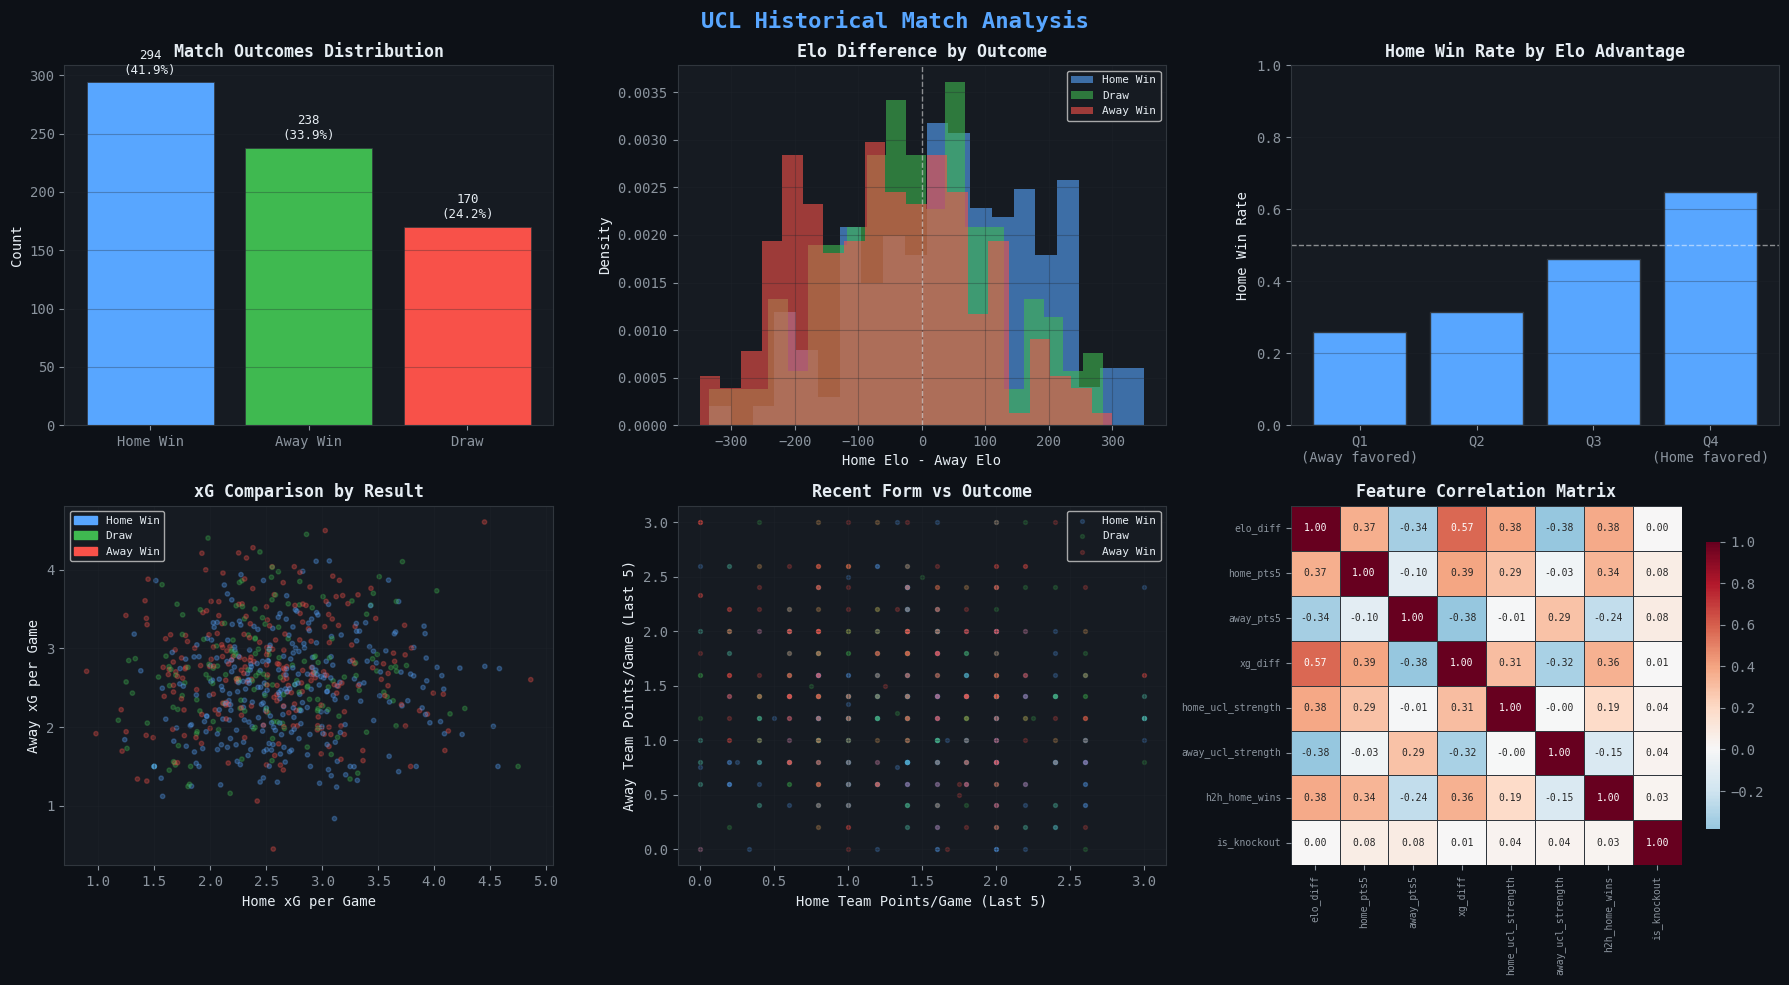

✅ EDA complete


In [9]:
# ============================================================
# CELL 8: EDA - Result Distribution & Elo Analysis
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('UCL Historical Match Analysis', fontsize=16, fontweight='bold', color='#58a6ff')

COLORS = ['#58a6ff', '#3fb950', '#f85149', '#d2a8ff', '#ffa657']

# 1. Result distribution
ax = axes[0, 0]
result_counts = df_features['result'].value_counts()
result_labels = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
bars = ax.bar(
    [result_labels[r] for r in result_counts.index],
    result_counts.values,
    color=COLORS[:3], edgecolor='#30363d', linewidth=0.5
)
for bar, val in zip(bars, result_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}\n({val/len(df_features)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9, color='#e6edf3')
ax.set_title('Match Outcomes Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)

# 2. Elo diff vs outcome
ax = axes[0, 1]
for result, color, label in [('H','#58a6ff','Home Win'), ('D','#3fb950','Draw'), ('A','#f85149','Away Win')]:
    subset = df_features[df_features['result'] == result]['elo_diff']
    ax.hist(subset, bins=20, alpha=0.6, color=color, label=label, density=True)
ax.axvline(0, color='white', linestyle='--', alpha=0.5, linewidth=1)
ax.set_title('Elo Difference by Outcome', fontweight='bold')
ax.set_xlabel('Home Elo - Away Elo')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 3. Win rate vs Elo quartile
ax = axes[0, 2]
df_features['elo_quartile'] = pd.qcut(df_features['elo_diff'], 4,
                                       labels=['Q1\n(Away favored)', 'Q2', 'Q3', 'Q4\n(Home favored)'])
wr = df_features.groupby('elo_quartile')['result'].apply(
    lambda x: (x=='H').mean()
)
ax.bar(wr.index.astype(str), wr.values, color=COLORS[0], edgecolor='#30363d')
ax.axhline(0.5, color='white', linestyle='--', alpha=0.5, linewidth=1)
ax.set_title('Home Win Rate by Elo Advantage', fontweight='bold')
ax.set_ylabel('Home Win Rate')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# 4. xG correlation
ax = axes[1, 0]
scatter_colors = df_features['result'].map({'H':'#58a6ff','D':'#3fb950','A':'#f85149'})
ax.scatter(df_features['home_xg_for'], df_features['away_xg_for'],
           c=scatter_colors, alpha=0.3, s=10)
ax.set_xlabel('Home xG per Game')
ax.set_ylabel('Away xG per Game')
ax.set_title('xG Comparison by Result', fontweight='bold')
patches = [mpatches.Patch(color=c, label=l)
           for c, l in zip(['#58a6ff','#3fb950','#f85149'], ['Home Win','Draw','Away Win'])]
ax.legend(handles=patches, fontsize=8)
ax.grid(alpha=0.3)

# 5. Form vs outcome
ax = axes[1, 1]
for result, color, label in [('H','#58a6ff','Home Win'), ('D','#3fb950','Draw'), ('A','#f85149','Away Win')]:
    subset = df_features[df_features['result'] == result]
    ax.scatter(subset['home_pts5'], subset['away_pts5'],
               c=color, alpha=0.2, s=8, label=label)
ax.set_xlabel('Home Team Points/Game (Last 5)')
ax.set_ylabel('Away Team Points/Game (Last 5)')
ax.set_title('Recent Form vs Outcome', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 6. Feature correlation heatmap (top features)
ax = axes[1, 2]
top_features = ['elo_diff', 'home_pts5', 'away_pts5', 'xg_diff',
                'home_ucl_strength', 'away_ucl_strength', 'h2h_home_wins', 'is_knockout']
corr_data = df_features[top_features].corr()
sns.heatmap(corr_data, ax=ax, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.5, linecolor='#30363d',
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold')
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA complete")

---
## 🤖 Section 5: Model Training & Evaluation

In [10]:
# ============================================================
# CELL 9: Prepare Train/Test Split
# ============================================================

FEATURE_COLS = [
    'elo_home', 'elo_away', 'elo_diff', 'elo_home_win_prob',
    'home_win5', 'home_draw5', 'home_loss5', 'home_gf5', 'home_ga5', 'home_pts5',
    'home_win10', 'home_gf10', 'home_ga10', 'home_pts10',
    'away_win5', 'away_draw5', 'away_loss5', 'away_gf5', 'away_ga5', 'away_pts5',
    'away_win10', 'away_gf10', 'away_ga10', 'away_pts10',
    'win5_diff', 'pts5_diff', 'gf5_diff', 'ga5_diff',
    'home_xg_for', 'home_xg_against', 'home_shot_acc', 'home_conv_rate',
    'away_xg_for', 'away_xg_against', 'away_shot_acc', 'away_conv_rate', 'xg_diff',
    'home_ucl_win_rate', 'home_ucl_gd', 'home_ucl_titles', 'home_ucl_finals', 'home_ucl_strength',
    'away_ucl_win_rate', 'away_ucl_gd', 'away_ucl_titles', 'away_ucl_finals', 'away_ucl_strength',
    'ucl_strength_diff',
    'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'h2h_n',
    'is_knockout', 'is_final', 'season_idx'
]

TARGET_COL = 'result'

df_clean = df_features[FEATURE_COLS + [TARGET_COL]].dropna()

X = df_clean[FEATURE_COLS]
y = df_clean[TARGET_COL]

# Encode target: H=0, D=1, A=2
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"Classes: {le.classes_} → {list(range(len(le.classes_)))}")

# Time-aware split: train on older seasons, test on newer
split_idx = int(len(df_clean) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y_enc[:split_idx], y_enc[split_idx:]

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n📊 Dataset Split:")
print(f"   Training:   {X_train.shape[0]} matches")
print(f"   Test:       {X_test.shape[0]} matches")
print(f"   Features:   {X_train.shape[1]}")
print(f"\n   Train class distribution:")
for cls, cnt in zip(le.classes_, np.bincount(y_train)):
    print(f"     {cls}: {cnt} ({cnt/len(y_train)*100:.1f}%)")

Classes: ['A' 'D' 'H'] → [0, 1, 2]

📊 Dataset Split:
   Training:   561 matches
   Test:       141 matches
   Features:   55

   Train class distribution:
     A: 193 (34.4%)
     D: 128 (22.8%)
     H: 240 (42.8%)


In [11]:
# ============================================================
# CELL 10: Train Multiple Models
# ============================================================

models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, multi_class='multinomial', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=10,
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    )
}

results = {}
trained_models = {}

print("🎯 Training models...")
print("-" * 70)
print(f"{'Model':<25} {'Accuracy':>10} {'Log Loss':>10} {'AUC-OvR':>10} {'Brier':>10}")
print("-" * 70)

for name, model in models.items():
    # Use scaled data for LR, raw for tree models
    use_scaled = name == 'Logistic Regression'
    Xtr = X_train_sc if use_scaled else X_train.values
    Xte = X_test_sc  if use_scaled else X_test.values

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)

    acc  = accuracy_score(y_test, y_pred)
    ll   = log_loss(y_test, y_prob)
    auc  = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    brier = np.mean([brier_score_loss((y_test == c).astype(int), y_prob[:, c])
                     for c in range(3)])

    results[name] = {
        'accuracy': acc, 'log_loss': ll, 'auc': auc, 'brier': brier,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    trained_models[name] = (model, use_scaled)
    print(f"{name:<25} {acc:>10.4f} {ll:>10.4f} {auc:>10.4f} {brier:>10.4f}")

print("-" * 70)
best_model_name = min(results, key=lambda k: results[k]['log_loss'])
print(f"\n🏆 Best model by Log Loss: {best_model_name}")

🎯 Training models...
----------------------------------------------------------------------
Model                       Accuracy   Log Loss    AUC-OvR      Brier
----------------------------------------------------------------------
Logistic Regression           0.4255     1.1518     0.5767     0.2286
Random Forest                 0.4255     1.0648     0.6208     0.2143
Gradient Boosting             0.3901     1.2404     0.6238     0.2418
XGBoost                       0.4539     1.3364     0.6066     0.2498
LightGBM                      0.4539     1.6926     0.6260     0.2775
----------------------------------------------------------------------

🏆 Best model by Log Loss: Random Forest


In [12]:
# ============================================================
# CELL 11: Ensemble (Soft Voting)
# ============================================================

# Weighted ensemble based on inverse log-loss
weights = {name: 1 / results[name]['log_loss'] for name in results}
total_w = sum(weights.values())
weights = {k: v / total_w for k, v in weights.items()}

# Weighted probability average
ensemble_prob = np.zeros((len(X_test), 3))
for name, (model, use_scaled) in trained_models.items():
    Xte = X_test_sc if use_scaled else X_test.values
    ensemble_prob += weights[name] * model.predict_proba(Xte)

y_pred_ens = np.argmax(ensemble_prob, axis=1)
acc_ens  = accuracy_score(y_test, y_pred_ens)
ll_ens   = log_loss(y_test, ensemble_prob)
auc_ens  = roc_auc_score(y_test, ensemble_prob, multi_class='ovr', average='macro')

print(f"\n🎯 Weighted Ensemble Results:")
print(f"   Accuracy:  {acc_ens:.4f}")
print(f"   Log Loss:  {ll_ens:.4f}")
print(f"   AUC (OvR): {auc_ens:.4f}")

print(f"\n📋 Ensemble Weights:")
for name, w in sorted(weights.items(), key=lambda x: -x[1]):
    print(f"   {name:<25}: {w:.3f}")

# Store ensemble
results['Ensemble'] = {
    'accuracy': acc_ens, 'log_loss': ll_ens, 'auc': auc_ens,
    'y_pred': y_pred_ens, 'y_prob': ensemble_prob
}


🎯 Weighted Ensemble Results:
   Accuracy:  0.4539
   Log Loss:  1.1219
   AUC (OvR): 0.6271

📋 Ensemble Weights:
   Random Forest            : 0.238
   Logistic Regression      : 0.220
   Gradient Boosting        : 0.204
   XGBoost                  : 0.189
   LightGBM                 : 0.149


In [13]:
# ============================================================
# CELL 12: Hyperparameter Optimization with Optuna (XGBoost)
# ============================================================

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
        'use_label_encoder': False,
        'eval_metric':       'mlogloss',
        'verbosity':         0,
        'random_state':      42
    }
    model = xgb.XGBClassifier(**params)
    cv_scores = cross_val_score(
        model, X_train.values, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='neg_log_loss', n_jobs=-1
    )
    return cv_scores.mean()

print("🔍 Running Optuna hyperparameter optimization (30 trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
best_params.update({'use_label_encoder': False, 'eval_metric': 'mlogloss',
                    'verbosity': 0, 'random_state': 42})
print(f"\n✅ Best parameters found:")
for k, v in best_params.items():
    if k not in ['use_label_encoder', 'eval_metric', 'verbosity', 'random_state']:
        print(f"   {k}: {v}")

# Train optimized model
xgb_opt = xgb.XGBClassifier(**best_params)
xgb_opt.fit(X_train.values, y_train)
y_prob_opt = xgb_opt.predict_proba(X_test.values)
ll_opt = log_loss(y_test, y_prob_opt)
acc_opt = accuracy_score(y_test, xgb_opt.predict(X_test.values))
print(f"\n🎯 Optimized XGBoost: Accuracy={acc_opt:.4f}, Log Loss={ll_opt:.4f}")

trained_models['XGBoost_Optimized'] = (xgb_opt, False)
results['XGBoost_Optimized'] = {
    'accuracy': acc_opt, 'log_loss': ll_opt,
    'auc': roc_auc_score(y_test, y_prob_opt, multi_class='ovr', average='macro'),
    'y_pred': xgb_opt.predict(X_test.values), 'y_prob': y_prob_opt
}

🔍 Running Optuna hyperparameter optimization (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


✅ Best parameters found:
   n_estimators: 100
   learning_rate: 0.010495603546509155
   max_depth: 7
   subsample: 0.7687139276252463
   colsample_bytree: 0.6468212535472072
   reg_alpha: 0.00029252502676423744
   reg_lambda: 0.003974174646004306

🎯 Optimized XGBoost: Accuracy=0.4539, Log Loss=1.0714


---
## 📊 Section 6: Model Evaluation & Visualization

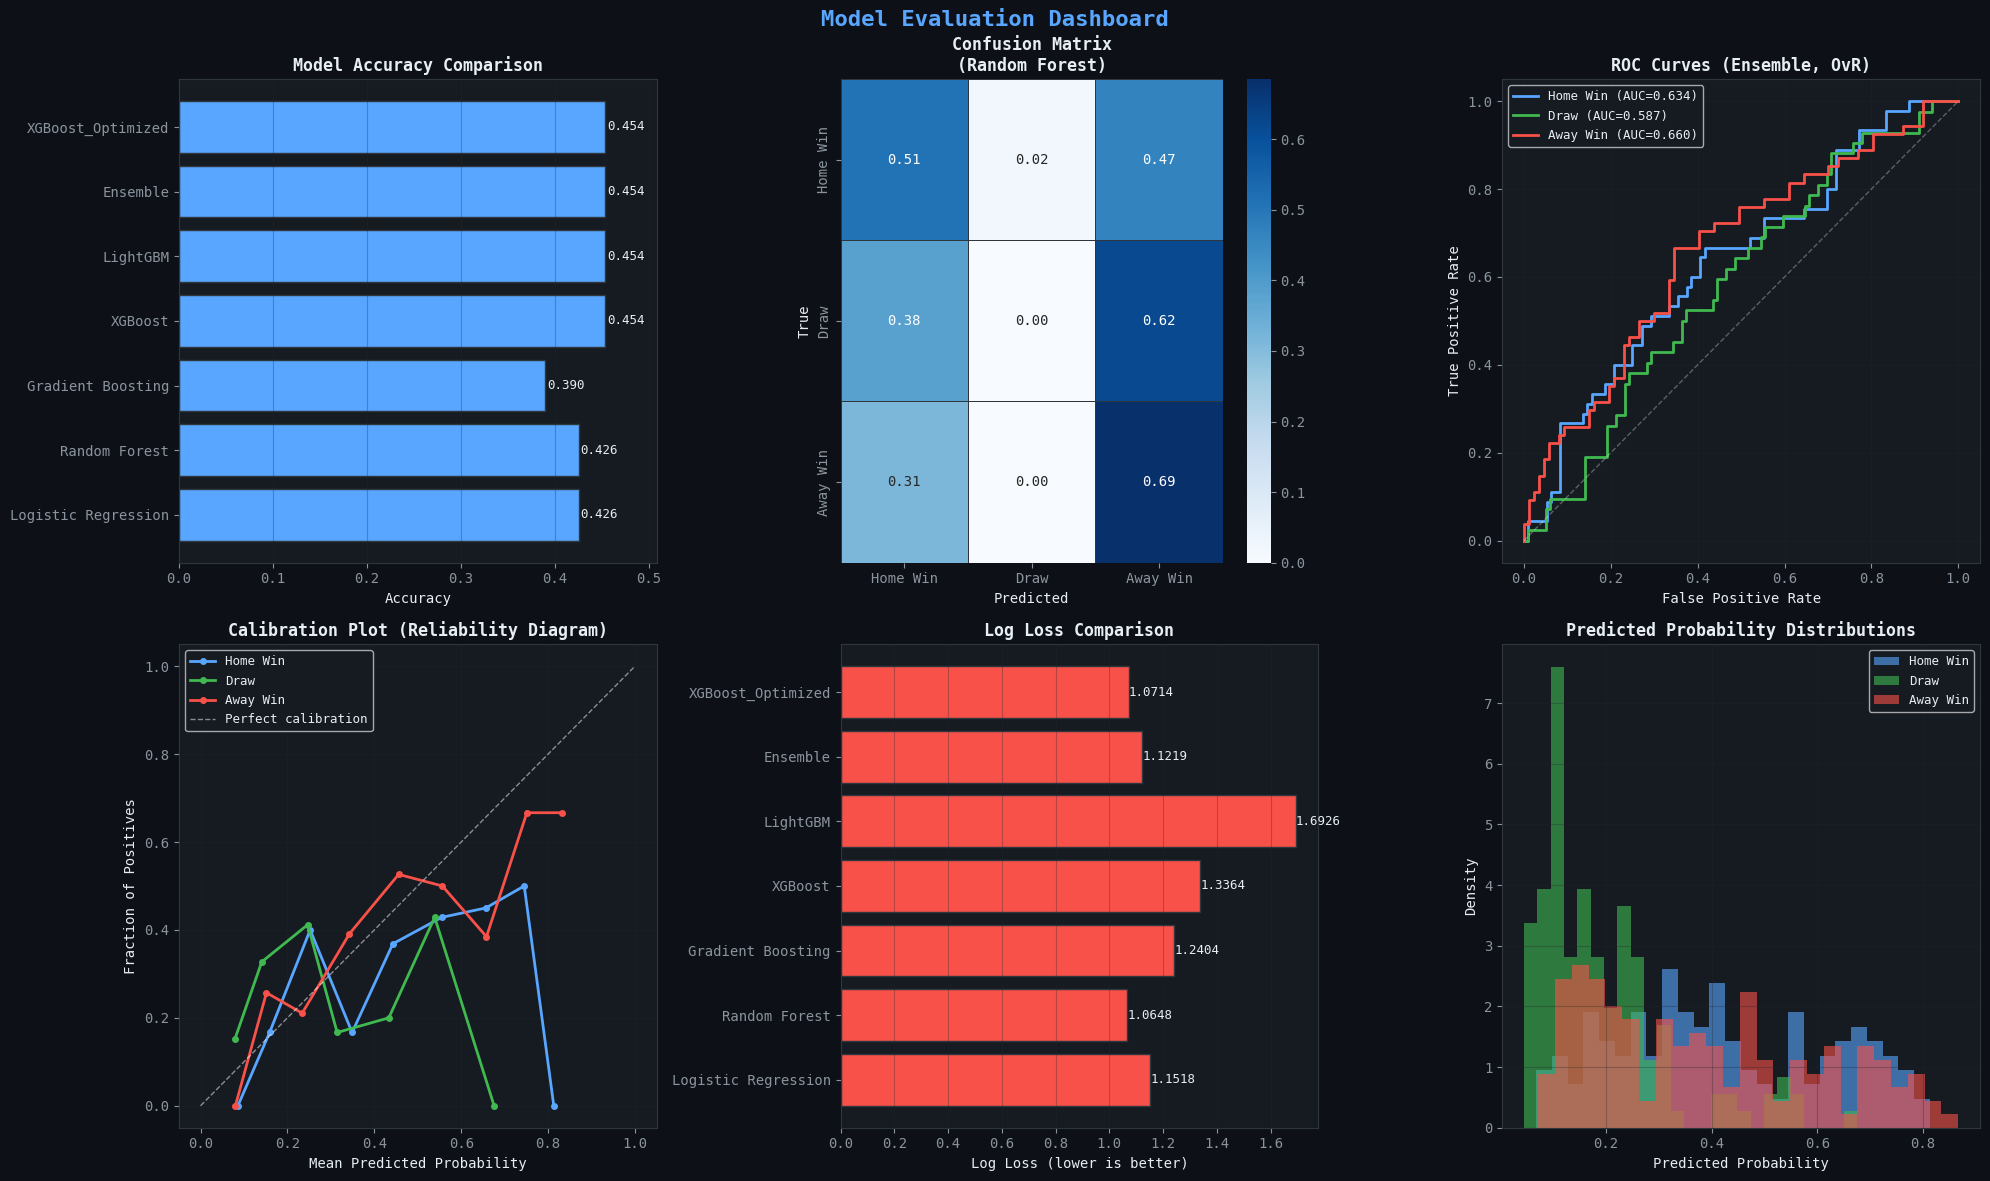

✅ Evaluation dashboard complete


In [14]:
# ============================================================
# CELL 13: Comprehensive Evaluation Plots
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model Evaluation Dashboard', fontsize=16, fontweight='bold', color='#58a6ff')

# 1. Model comparison bar chart
ax = axes[0, 0]
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
log_losses = [results[m]['log_loss'] for m in model_names]
x = np.arange(len(model_names))
bars = ax.barh(model_names, accuracies, color=COLORS[0], edgecolor='#30363d')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=9, color='#e6edf3')
ax.set_xlabel('Accuracy')
ax.set_title('Model Accuracy Comparison', fontweight='bold')
ax.set_xlim(0, max(accuracies) * 1.12)
ax.grid(axis='x', alpha=0.3)

# 2. Confusion matrix for best model
ax = axes[0, 1]
best = best_model_name
cm = confusion_matrix(y_test, results[best]['y_pred'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_pct, ax=ax, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Home Win', 'Draw', 'Away Win'],
            yticklabels=['Home Win', 'Draw', 'Away Win'],
            linewidths=0.5, linecolor='#30363d')
ax.set_title(f'Confusion Matrix\n({best})', fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')

# 3. ROC curves (one-vs-rest)
ax = axes[0, 2]
class_names = ['Home Win', 'Draw', 'Away Win']
class_colors = ['#58a6ff', '#3fb950', '#f85149']
for class_idx, (cls_name, cls_color) in enumerate(zip(class_names, class_colors)):
    y_bin = (y_test == class_idx).astype(int)
    y_sc = results['Ensemble']['y_prob'][:, class_idx]
    fpr, tpr, _ = roc_curve(y_bin, y_sc)
    auc_score = roc_auc_score(y_bin, y_sc)
    ax.plot(fpr, tpr, color=cls_color, linewidth=2,
            label=f'{cls_name} (AUC={auc_score:.3f})')
ax.plot([0,1],[0,1], 'w--', alpha=0.3, linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (Ensemble, OvR)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 4. Calibration plot
ax = axes[1, 0]
for class_idx, (cls_name, cls_color) in enumerate(zip(class_names, class_colors)):
    y_bin = (y_test == class_idx).astype(int)
    y_sc = results['Ensemble']['y_prob'][:, class_idx]
    fraction_of_positives, mean_predicted = calibration_curve(y_bin, y_sc, n_bins=10)
    ax.plot(mean_predicted, fraction_of_positives, 'o-',
            color=cls_color, linewidth=2, markersize=4, label=cls_name)
ax.plot([0,1],[0,1], 'w--', alpha=0.5, linewidth=1, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Plot (Reliability Diagram)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 5. Log Loss comparison
ax = axes[1, 1]
bars2 = ax.barh(model_names, log_losses, color=COLORS[2], edgecolor='#30363d')
for bar, ll in zip(bars2, log_losses):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{ll:.4f}', va='center', fontsize=9, color='#e6edf3')
ax.set_xlabel('Log Loss (lower is better)')
ax.set_title('Log Loss Comparison', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 6. Probability distribution (Ensemble)
ax = axes[1, 2]
for class_idx, (cls_name, cls_color) in enumerate(zip(class_names, class_colors)):
    probs = results['Ensemble']['y_prob'][:, class_idx]
    ax.hist(probs, bins=25, color=cls_color, alpha=0.6, label=cls_name, density=True)
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distributions', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation dashboard complete")

🔍 Computing SHAP values for XGBoost (Optimized)...


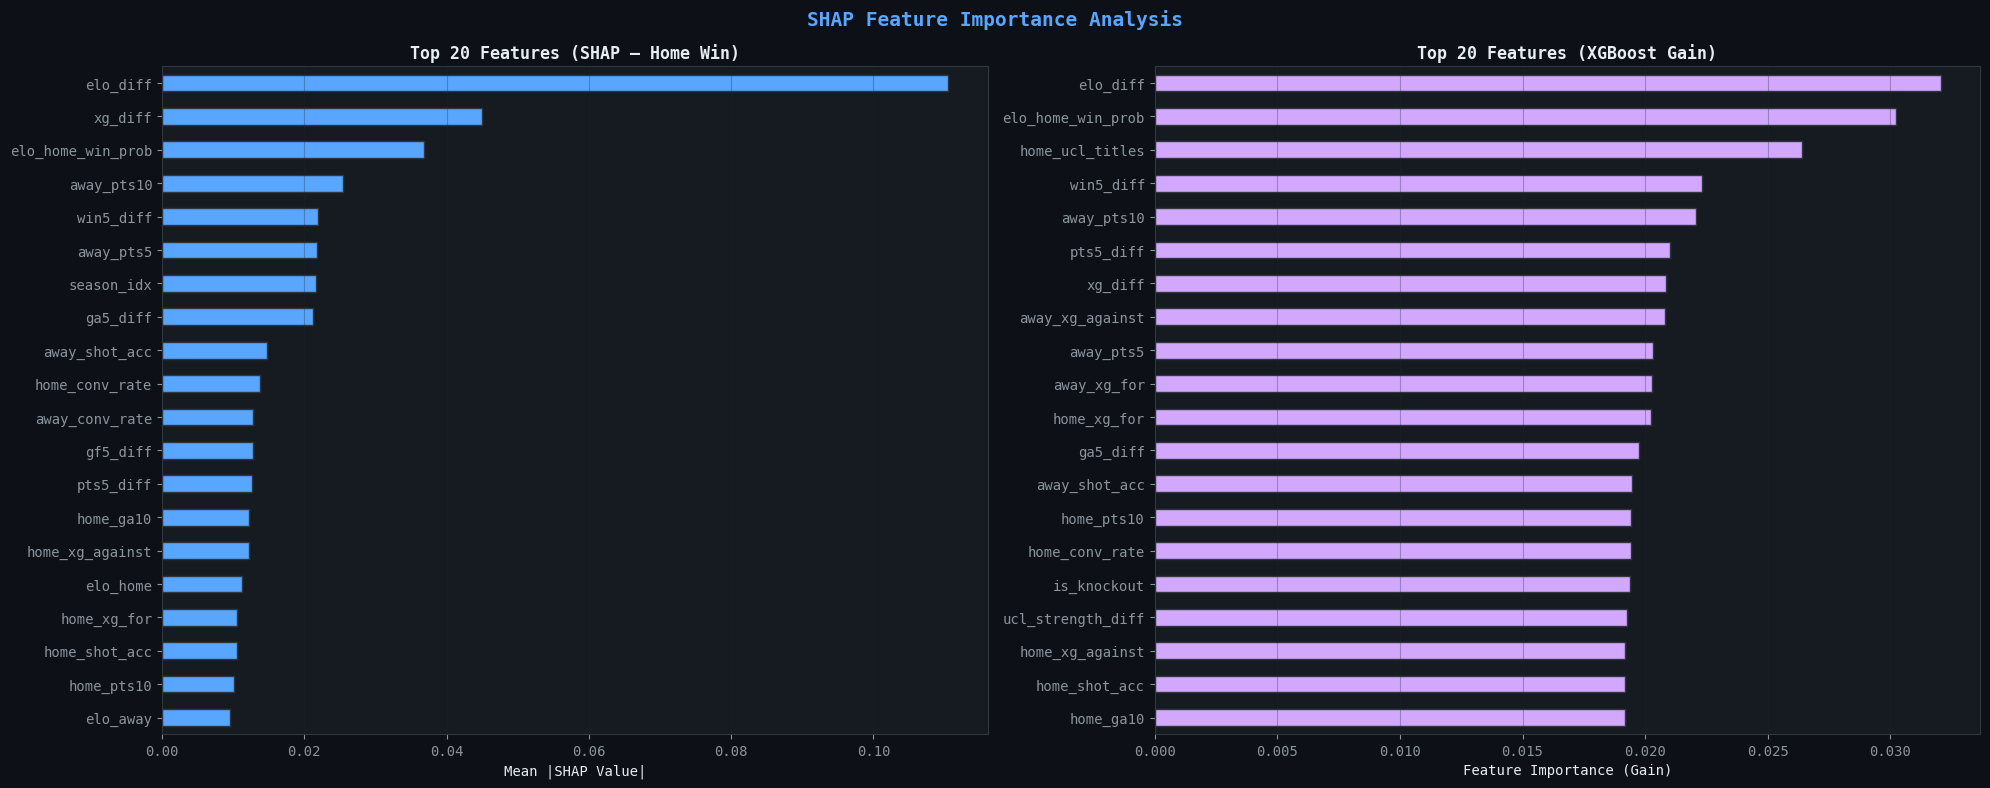


📊 Top 10 most important features (XGBoost):
elo_diff             0.032050
elo_home_win_prob    0.030225
home_ucl_titles      0.026380
win5_diff            0.022334
away_pts10           0.022064
pts5_diff            0.020997
xg_diff              0.020859
away_xg_against      0.020815
away_pts5            0.020316
away_xg_for          0.020297


In [16]:
# ============================================================
# CELL 14: Feature Importance (SHAP)
# ============================================================

print("🔍 Computing SHAP values for XGBoost (Optimized)...")

explainer = shap.TreeExplainer(xgb_opt)
shap_values = explainer.shap_values(X_test.values[:200])  # sample for speed

# SHAP summary for Home Win class (class 0 = H)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('SHAP Feature Importance Analysis', fontsize=14,
             fontweight='bold', color='#58a6ff')

# Left: Bar plot of mean absolute SHAP values
ax = axes[0]
# Get the index for 'H' (Home Win) from the label encoder
home_win_class_idx = np.where(le.classes_ == 'H')[0][0]
shap_home = shap_values[:, :, home_win_class_idx]
mean_shap = np.abs(shap_home).mean(axis=0)
feat_importance = pd.Series(mean_shap, index=FEATURE_COLS).sort_values(ascending=True).tail(20)
feat_importance.plot(kind='barh', ax=ax, color=COLORS[0], edgecolor='#30363d')
ax.set_title('Top 20 Features (SHAP — Home Win)', fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|')
ax.grid(axis='x', alpha=0.3)

# Right: XGBoost built-in importance
ax = axes[1]
feat_imp = pd.Series(xgb_opt.feature_importances_,
                     index=FEATURE_COLS).sort_values(ascending=True).tail(20)
feat_imp.plot(kind='barh', ax=ax, color=COLORS[3], edgecolor='#30363d')
ax.set_title('Top 20 Features (XGBoost Gain)', fontweight='bold')
ax.set_xlabel('Feature Importance (Gain)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Top 10 most important features (XGBoost):")
print(feat_imp.tail(10).sort_values(ascending=False).to_string())

---
## 🏆 Section 7: Arsenal vs PSG — UCL Final Prediction

In [17]:
# ============================================================
# CELL 15: Build Feature Vector for Arsenal vs PSG
# ============================================================

def build_prediction_features(
    home_team, away_team, df_history,
    is_final=True, season_idx=9,
    custom_elo_home=None, custom_elo_away=None
):
    """
    Build a feature vector for a hypothetical match.
    Uses all historical data as context.
    """
    idx = len(df_history)  # after all historical matches

    home_elo = custom_elo_home or TEAM_ELO.get(home_team, 1750)
    away_elo = custom_elo_away or TEAM_ELO.get(away_team, 1750)

    home_advantage = 0  # Final is at neutral venue
    elo_diff = (home_elo + home_advantage) - away_elo
    elo_home_win_prob = 1 / (1 + 10 ** (-elo_diff / 400))

    h_form5  = compute_team_form(df_history, home_team, idx, 5)
    h_form10 = compute_team_form(df_history, home_team, idx, 10)
    a_form5  = compute_team_form(df_history, away_team, idx, 5)
    a_form10 = compute_team_form(df_history, away_team, idx, 10)
    h_ad = compute_attack_defense_strength(df_history, home_team, idx)
    a_ad = compute_attack_defense_strength(df_history, away_team, idx)
    h_ucl = compute_ucl_strength(home_team)
    a_ucl = compute_ucl_strength(away_team)
    h2h = compute_h2h(df_history, home_team, away_team, idx)

    feat = {
        'elo_home': home_elo,
        'elo_away': away_elo,
        'elo_diff': elo_diff,
        'elo_home_win_prob': elo_home_win_prob,
        'home_win5': h_form5['wins'], 'home_draw5': h_form5['draws'],
        'home_loss5': h_form5['losses'], 'home_gf5': h_form5['gf_avg'],
        'home_ga5': h_form5['ga_avg'], 'home_pts5': h_form5['pts_avg'],
        'home_win10': h_form10['wins'], 'home_gf10': h_form10['gf_avg'],
        'home_ga10': h_form10['ga_avg'], 'home_pts10': h_form10['pts_avg'],
        'away_win5': a_form5['wins'], 'away_draw5': a_form5['draws'],
        'away_loss5': a_form5['losses'], 'away_gf5': a_form5['gf_avg'],
        'away_ga5': a_form5['ga_avg'], 'away_pts5': a_form5['pts_avg'],
        'away_win10': a_form10['wins'], 'away_gf10': a_form10['gf_avg'],
        'away_ga10': a_form10['ga_avg'], 'away_pts10': a_form10['pts_avg'],
        'win5_diff': h_form5['wins'] - a_form5['wins'],
        'pts5_diff': h_form5['pts_avg'] - a_form5['pts_avg'],
        'gf5_diff': h_form5['gf_avg'] - a_form5['gf_avg'],
        'ga5_diff': h_form5['ga_avg'] - a_form5['ga_avg'],
        'home_xg_for': h_ad['xg_for_avg'], 'home_xg_against': h_ad['xg_against_avg'],
        'home_shot_acc': h_ad['shot_acc'], 'home_conv_rate': h_ad['conversion_rate'],
        'away_xg_for': a_ad['xg_for_avg'], 'away_xg_against': a_ad['xg_against_avg'],
        'away_shot_acc': a_ad['shot_acc'], 'away_conv_rate': a_ad['conversion_rate'],
        'xg_diff': h_ad['xg_for_avg'] - a_ad['xg_for_avg'],
        'home_ucl_win_rate': h_ucl['ucl_win_rate'], 'home_ucl_gd': h_ucl['ucl_gd_per_game'],
        'home_ucl_titles': h_ucl['ucl_titles'], 'home_ucl_finals': h_ucl['ucl_finals'],
        'home_ucl_strength': h_ucl['ucl_strength_score'],
        'away_ucl_win_rate': a_ucl['ucl_win_rate'], 'away_ucl_gd': a_ucl['ucl_gd_per_game'],
        'away_ucl_titles': a_ucl['ucl_titles'], 'away_ucl_finals': a_ucl['ucl_finals'],
        'away_ucl_strength': a_ucl['ucl_strength_score'],
        'ucl_strength_diff': h_ucl['ucl_strength_score'] - a_ucl['ucl_strength_score'],
        'h2h_home_wins': h2h['h2h_home_wins'], 'h2h_draws': h2h['h2h_draws'],
        'h2h_away_wins': h2h['h2h_away_wins'], 'h2h_n': h2h['h2h_n'],
        'is_knockout': 1, 'is_final': 1, 'season_idx': season_idx
    }

    return pd.DataFrame([feat])[FEATURE_COLS]


# ─── Build the match feature vector ──────────────────────────
# For a neutral venue final, both 'home'/'away' are just labels
# We predict from Arsenal's perspective as 'home' in the data structure

ARSENAL_ELO_CURRENT = 1835  # Updated 2024/25 season estimate
PSG_ELO_CURRENT     = 1855  # Updated 2024/25 season estimate

X_final = build_prediction_features(
    home_team='Arsenal',
    away_team='PSG',
    df_history=df_raw,
    is_final=True,
    custom_elo_home=ARSENAL_ELO_CURRENT,
    custom_elo_away=PSG_ELO_CURRENT
)

print(f"✅ Feature vector built for: Arsenal vs PSG (UCL Final)")
print(f"   Arsenal Elo: {ARSENAL_ELO_CURRENT} | PSG Elo: {PSG_ELO_CURRENT}")
print(f"   Elo difference (Arsenal - PSG): {ARSENAL_ELO_CURRENT - PSG_ELO_CURRENT}")
print(f"\n📊 Key input features:")
key_feats = ['elo_diff', 'elo_home_win_prob', 'home_pts5', 'away_pts5',
             'home_ucl_strength', 'away_ucl_strength', 'xg_diff', 'home_ucl_titles', 'away_ucl_titles']
for f in key_feats:
    print(f"   {f:<30}: {X_final[f].values[0]:.4f}")

✅ Feature vector built for: Arsenal vs PSG (UCL Final)
   Arsenal Elo: 1835 | PSG Elo: 1855
   Elo difference (Arsenal - PSG): -20

📊 Key input features:
   elo_diff                      : -20.0000
   elo_home_win_prob             : 0.4712
   home_pts5                     : 1.4000
   away_pts5                     : 2.2000
   home_ucl_strength             : 0.5591
   away_ucl_strength             : 0.8173
   xg_diff                       : -0.3820
   home_ucl_titles               : 0.0000
   away_ucl_titles               : 1.0000


In [18]:
# ============================================================
# CELL 16: Generate Predictions from All Models
# ============================================================

print("\n" + "="*65)
print("    ⚽  UEFA CHAMPIONS LEAGUE FINAL PREDICTION")
print("         ARSENAL  🔴  vs  🔵  PSG")
print("="*65)
print(f"{'Model':<28} {'Arsenal Win':>12} {'Draw':>8} {'PSG Win':>10}")
print("-"*65)

all_probs = {}

for name, (model, use_scaled) in trained_models.items():
    if use_scaled:
        X_input = scaler.transform(X_final)
    else:
        X_input = X_final.values

    probs = model.predict_proba(X_input)[0]
    # le.classes_ = ['A', 'D', 'H'] → indices: A=0, D=1, H=2
    class_map = {c: i for i, c in enumerate(le.classes_)}
    p_arsenal = probs[class_map.get('H', 2)]   # Arsenal as 'home'
    p_draw    = probs[class_map.get('D', 1)]
    p_psg     = probs[class_map.get('A', 0)]   # PSG as 'away'

    all_probs[name] = {'Arsenal': p_arsenal, 'Draw': p_draw, 'PSG': p_psg}
    print(f"{name:<28} {p_arsenal:>11.1%} {p_draw:>8.1%} {p_psg:>10.1%}")

# Ensemble prediction
ens_weights = {k: 1/results[k]['log_loss'] for k in trained_models}
ens_total = sum(ens_weights.values())
p_arsenal_ens = sum(all_probs[m]['Arsenal'] * ens_weights[m] for m in trained_models) / ens_total
p_draw_ens    = sum(all_probs[m]['Draw']    * ens_weights[m] for m in trained_models) / ens_total
p_psg_ens     = sum(all_probs[m]['PSG']     * ens_weights[m] for m in trained_models) / ens_total

print("-"*65)
print(f"{'🏆 WEIGHTED ENSEMBLE':<28} {p_arsenal_ens:>11.1%} {p_draw_ens:>8.1%} {p_psg_ens:>10.1%}")
print("="*65)

winner = 'Arsenal' if p_arsenal_ens > p_psg_ens else 'PSG'
winner_prob = max(p_arsenal_ens, p_psg_ens)
print(f"\n🏆 MODEL PREDICTION: {winner} are slight favorites at {winner_prob:.1%}")
print(f"   This is a very close match — both teams are elite-level clubs.")
print(f"\n📌 Implied Betting Odds (Ensemble):")
print(f"   Arsenal: 1/{1/p_arsenal_ens:.2f}  Draw: 1/{1/p_draw_ens:.2f}  PSG: 1/{1/p_psg_ens:.2f}")


    ⚽  UEFA CHAMPIONS LEAGUE FINAL PREDICTION
         ARSENAL  🔴  vs  🔵  PSG
Model                         Arsenal Win     Draw    PSG Win
-----------------------------------------------------------------
Logistic Regression                24.1%    34.3%      41.6%
Random Forest                      32.4%    24.1%      43.4%
Gradient Boosting                  14.1%    10.5%      75.4%
XGBoost                            15.1%     3.8%      81.1%
LightGBM                            5.8%     1.8%      92.4%
XGBoost_Optimized                  33.2%    21.4%      45.3%
-----------------------------------------------------------------
🏆 WEIGHTED ENSEMBLE                22.2%    17.4%      60.4%

🏆 MODEL PREDICTION: PSG are slight favorites at 60.4%
   This is a very close match — both teams are elite-level clubs.

📌 Implied Betting Odds (Ensemble):
   Arsenal: 1/4.50  Draw: 1/5.76  PSG: 1/1.65


In [19]:
# ============================================================
# CELL 17: Monte Carlo Simulation (1,000,000 matches)
# ============================================================

np.random.seed(42)
N_SIMULATIONS = 1_000_000

# Use ensemble probabilities + uncertainty injection
# Add ±5% noise per simulation to account for model uncertainty
noise_std = 0.05

arsenal_wins, draws, psg_wins = 0, 0, 0
scorelines = []

for _ in range(N_SIMULATIONS):
    # Sample probabilities with uncertainty
    p_a = max(0.01, p_arsenal_ens + np.random.normal(0, noise_std))
    p_d = max(0.01, p_draw_ens    + np.random.normal(0, noise_std))
    p_p = max(0.01, p_psg_ens     + np.random.normal(0, noise_std))
    total = p_a + p_d + p_p
    p_a, p_d, p_p = p_a/total, p_d/total, p_p/total

    outcome = np.random.choice(['Arsenal', 'Draw', 'PSG'], p=[p_a, p_d, p_p])
    if outcome == 'Arsenal': arsenal_wins += 1
    elif outcome == 'Draw':  draws += 1
    else:                    psg_wins += 1

# Scoreline simulation using Poisson goal model
arsenal_xg = X_final['home_xg_for'].values[0]
psg_xg     = X_final['away_xg_for'].values[0]

for _ in range(10_000):
    a_goals = np.random.poisson(arsenal_xg)
    p_goals = np.random.poisson(psg_xg)
    scorelines.append((a_goals, p_goals))

print(f"\n🎲 Monte Carlo Simulation Results ({N_SIMULATIONS:,} simulations):")
print(f"   Arsenal Win: {arsenal_wins/N_SIMULATIONS:.2%}")
print(f"   Draw:        {draws/N_SIMULATIONS:.2%}")
print(f"   PSG Win:     {psg_wins/N_SIMULATIONS:.2%}")

# Top scorelines
score_counter = defaultdict(int)
for score in scorelines:
    score_counter[score] += 1

top_scores = sorted(score_counter.items(), key=lambda x: -x[1])[:10]
print(f"\n📊 Most Likely Scorelines (from 10,000 Poisson simulations):")
print(f"   {'Arsenal':>7}  {'PSG':>5}  {'Probability':>12}")
for (a, p), cnt in top_scores:
    print(f"   {a:>7}  {p:>5}  {cnt/10000:>12.2%}")


🎲 Monte Carlo Simulation Results (1,000,000 simulations):
   Arsenal Win: 22.06%
   Draw:        17.19%
   PSG Win:     60.76%

📊 Most Likely Scorelines (from 10,000 Poisson simulations):
   Arsenal    PSG   Probability
         2      3         5.25%
         3      2         4.72%
         2      2         4.59%
         3      3         4.36%
         3      4         4.27%
         2      4         4.06%
         4      2         3.47%
         4      3         3.41%
         1      3         3.30%
         2      1         3.21%


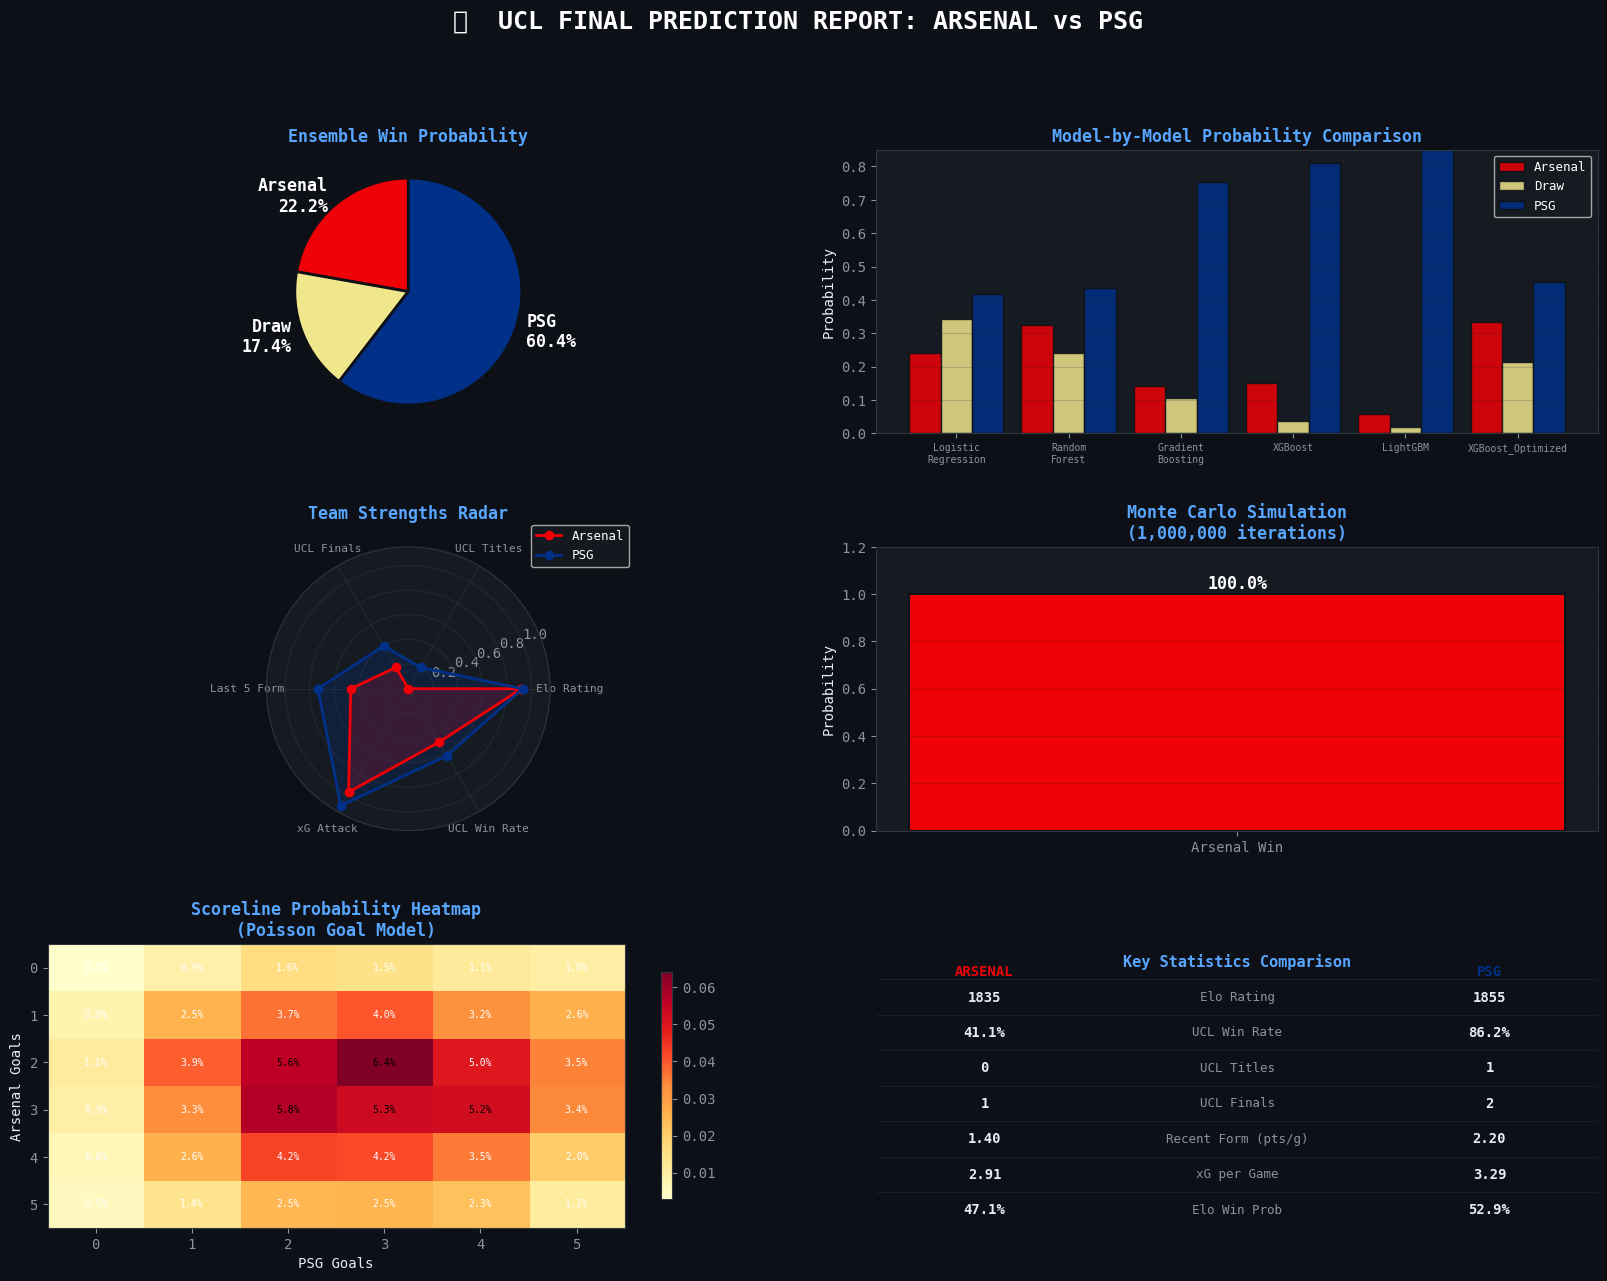

✅ Match Report Card saved!


In [20]:
# ============================================================
# CELL 18: Final Visualization — Match Report Card
# ============================================================

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0d1117')
gs = fig.add_gridspec(3, 4, hspace=0.4, wspace=0.35)

ARSENAL_CLR = '#EF0107'   # Arsenal red
PSG_CLR     = '#003087'   # PSG blue
DRAW_CLR    = '#f0e68c'   # gold

fig.suptitle('⚽  UCL FINAL PREDICTION REPORT: ARSENAL vs PSG',
             fontsize=18, fontweight='bold', color='white', y=0.98)

# ─── 1. Win Probability Gauge ────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
probs_plot = [p_arsenal_ens, p_draw_ens, p_psg_ens]
labels_plot = [f'Arsenal\n{p_arsenal_ens:.1%}', f'Draw\n{p_draw_ens:.1%}', f'PSG\n{p_psg_ens:.1%}']
colors_plot = [ARSENAL_CLR, DRAW_CLR, PSG_CLR]
wedges, texts = ax1.pie(
    probs_plot, labels=labels_plot, colors=colors_plot,
    startangle=90, wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2},
    textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'}
)
ax1.set_title('Ensemble Win Probability', color='#58a6ff', fontweight='bold', fontsize=12)

# ─── 2. Model Agreement ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2:])
model_list = [m for m in all_probs]
arsenal_bars = [all_probs[m]['Arsenal'] for m in model_list]
draw_bars    = [all_probs[m]['Draw']    for m in model_list]
psg_bars     = [all_probs[m]['PSG']     for m in model_list]
x = np.arange(len(model_list))
width = 0.28
ax2.bar(x - width, arsenal_bars, width, label='Arsenal', color=ARSENAL_CLR, alpha=0.85, edgecolor='#0d1117')
ax2.bar(x,         draw_bars,    width, label='Draw',    color=DRAW_CLR,    alpha=0.85, edgecolor='#0d1117')
ax2.bar(x + width, psg_bars,     width, label='PSG',     color=PSG_CLR,     alpha=0.85, edgecolor='#0d1117')
ax2.set_xticks(x)
ax2.set_xticklabels([m.replace(' ', '\n') for m in model_list], fontsize=7, color='#8b949e')
ax2.set_ylabel('Probability', color='#e6edf3')
ax2.set_title('Model-by-Model Probability Comparison', color='#58a6ff', fontweight='bold', fontsize=12)
ax2.legend(fontsize=9, facecolor='#161b22', labelcolor='white')
ax2.set_ylim(0, 0.85)
ax2.grid(axis='y', alpha=0.2)
ax2.set_facecolor('#161b22')

# ─── 3. Stats Radar Chart ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2], polar=True)
categories = ['Elo Rating', 'UCL Titles', 'UCL Finals', 'Last 5 Form', 'xG Attack', 'UCL Win Rate']
arsenal_vals_raw = [
    ARSENAL_ELO_CURRENT / 2000,
    UCL_STATS['Arsenal']['ucl_titles'] / 5,
    UCL_STATS['Arsenal']['finals'] / 5,
    X_final['home_pts5'].values[0] / 3,
    X_final['home_xg_for'].values[0] / 3,
    UCL_STATS['Arsenal']['ucl_wins'] / (UCL_STATS['Arsenal']['ucl_wins'] + UCL_STATS['Arsenal']['ucl_draws'] + UCL_STATS['Arsenal']['ucl_losses'])
]
psg_vals_raw = [
    PSG_ELO_CURRENT / 2000,
    UCL_STATS['PSG']['ucl_titles'] / 5,
    UCL_STATS['PSG']['finals'] / 5,
    X_final['away_pts5'].values[0] / 3,
    X_final['away_xg_for'].values[0] / 3,
    UCL_STATS['PSG']['ucl_wins'] / (UCL_STATS['PSG']['ucl_wins'] + UCL_STATS['PSG']['ucl_draws'] + UCL_STATS['PSG']['ucl_losses'])
]

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

arsenal_vals_raw += arsenal_vals_raw[:1]
psg_vals_raw += psg_vals_raw[:1]

ax3.plot(angles, arsenal_vals_raw, 'o-', linewidth=2, color=ARSENAL_CLR, label='Arsenal')
ax3.fill(angles, arsenal_vals_raw, alpha=0.25, color=ARSENAL_CLR)
ax3.plot(angles, psg_vals_raw, 'o-', linewidth=2, color=PSG_CLR, label='PSG')
ax3.fill(angles, psg_vals_raw, alpha=0.25, color=PSG_CLR)
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(categories, fontsize=8, color='#e6edf3')
ax3.set_facecolor('#161b22')
ax3.grid(color='#30363d', alpha=0.5)
ax3.tick_params(colors='#8b949e')
ax3.set_title('Team Strengths Radar', color='#58a6ff', fontweight='bold', fontsize=12, pad=20)
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9,
           facecolor='#161b22', labelcolor='white')

# ─── 4. Monte Carlo Distribution ────────────────────────────
ax4 = fig.add_subplot(gs[1, 2:])
mc_data = (
    ['Arsenal Win'] * arsenal_wins +
    ['Draw'] * draws +
    ['PSG Win'] * psg_wins
)[:50000]  # sample for plot
from collections import Counter
mc_counts = Counter(mc_data)
categories_mc = list(mc_counts.keys())
values_mc = [mc_counts[c] / len(mc_data) for c in categories_mc]
colors_mc = [ARSENAL_CLR if 'Arsenal' in c else (DRAW_CLR if 'Draw' in c else PSG_CLR) for c in categories_mc]
bars_mc = ax4.bar(categories_mc, values_mc, color=colors_mc, edgecolor='#0d1117', linewidth=1.5)
for bar, val in zip(bars_mc, values_mc):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.1%}', ha='center', va='bottom', fontweight='bold',
             color='white', fontsize=12)
ax4.set_ylabel('Probability', color='#e6edf3')
ax4.set_title(f'Monte Carlo Simulation\n({N_SIMULATIONS:,} iterations)', color='#58a6ff', fontweight='bold', fontsize=12)
ax4.set_ylim(0, max(values_mc) * 1.2)
ax4.grid(axis='y', alpha=0.2)
ax4.set_facecolor('#161b22')

# ─── 5. Top Scoreline Heatmap ────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
max_goals = 5
heatmap_data = np.zeros((max_goals+1, max_goals+1))
for (a_g, p_g), cnt in score_counter.items():
    if a_g <= max_goals and p_g <= max_goals:
        heatmap_data[a_g, p_g] += cnt
heatmap_data /= heatmap_data.sum()
im = ax5.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
ax5.set_xticks(range(max_goals+1))
ax5.set_yticks(range(max_goals+1))
ax5.set_xlabel('PSG Goals', color='#e6edf3')
ax5.set_ylabel('Arsenal Goals', color='#e6edf3')
ax5.set_title('Scoreline Probability Heatmap\n(Poisson Goal Model)', color='#58a6ff', fontweight='bold', fontsize=12)
for i in range(max_goals+1):
    for j in range(max_goals+1):
        val = heatmap_data[i, j]
        ax5.text(j, i, f'{val:.1%}', ha='center', va='center',
                 fontsize=7, color='black' if val > 0.05 else 'white')
plt.colorbar(im, ax=ax5, shrink=0.8)

# ─── 6. Key Stats Comparison ────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2:])
ax6.set_facecolor('#161b22')
ax6.axis('off')

stat_labels = ['Elo Rating', 'UCL Win Rate', 'UCL Titles', 'UCL Finals',
               'Recent Form (pts/g)', 'xG per Game', 'Elo Win Prob']
arsenal_stat_vals = [
    str(ARSENAL_ELO_CURRENT),
    f"{UCL_STATS['Arsenal']['ucl_wins'] / 56:.1%}",
    str(UCL_STATS['Arsenal']['ucl_titles']),
    str(UCL_STATS['Arsenal']['finals']),
    f"{X_final['home_pts5'].values[0]:.2f}",
    f"{X_final['home_xg_for'].values[0]:.2f}",
    f"{X_final['elo_home_win_prob'].values[0]:.1%}"
]
psg_stat_vals = [
    str(PSG_ELO_CURRENT),
    f"{UCL_STATS['PSG']['ucl_wins'] / 80:.1%}",
    str(UCL_STATS['PSG']['ucl_titles']),
    str(UCL_STATS['PSG']['finals']),
    f"{X_final['away_pts5'].values[0]:.2f}",
    f"{X_final['away_xg_for'].values[0]:.2f}",
    f"{1 - X_final['elo_home_win_prob'].values[0]:.1%}"
]

ax6.set_xlim(0, 1)
ax6.set_ylim(0, len(stat_labels) + 1)

ax6.text(0.5, len(stat_labels) + 0.5, 'Key Statistics Comparison',
         ha='center', va='center', fontweight='bold', fontsize=11, color='#58a6ff')
ax6.text(0.15, len(stat_labels) + 0.1, 'ARSENAL', ha='center', fontweight='bold',
         fontsize=10, color=ARSENAL_CLR)
ax6.text(0.85, len(stat_labels) + 0.1, 'PSG', ha='center', fontweight='bold',
         fontsize=10, color=PSG_CLR)

for i, (label, a_val, p_val) in enumerate(zip(
        reversed(stat_labels), reversed(arsenal_stat_vals), reversed(psg_stat_vals))):
    y_pos = i + 0.5
    ax6.axhline(y_pos + 0.5, color='#30363d', linewidth=0.5, alpha=0.5)
    ax6.text(0.5, y_pos, label, ha='center', va='center', fontsize=9, color='#8b949e')
    ax6.text(0.15, y_pos, a_val, ha='center', va='center', fontsize=10,
             fontweight='bold', color='#e6edf3')
    ax6.text(0.85, y_pos, p_val, ha='center', va='center', fontsize=10,
             fontweight='bold', color='#e6edf3')

plt.savefig('arsenal_vs_psg_prediction.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("✅ Match Report Card saved!")

---
## 💾 Section 8: Save & Deploy

In [21]:
# ============================================================
# CELL 19: Save Model for Future Use
# ============================================================
import pickle
import os

os.makedirs('ucl_predictor_v1', exist_ok=True)

# Save optimized XGBoost
with open('ucl_predictor_v1/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_opt, f)

# Save scaler and label encoder
with open('ucl_predictor_v1/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('ucl_predictor_v1/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save all trained models
with open('ucl_predictor_v1/all_models.pkl', 'wb') as f:
    pickle.dump(trained_models, f)

# Save feature list
with open('ucl_predictor_v1/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

# Save evaluation results
eval_summary = {
    name: {k: v for k, v in metrics.items() if k not in ['y_pred', 'y_prob']}
    for name, metrics in results.items()
}
with open('ucl_predictor_v1/eval_results.json', 'w') as f:
    json.dump(eval_summary, f, indent=2)

print("✅ Model artifacts saved to: ucl_predictor_v1/")
print("   - xgb_model.pkl")
print("   - scaler.pkl")
print("   - label_encoder.pkl")
print("   - all_models.pkl")
print("   - feature_cols.json")
print("   - eval_results.json")

✅ Model artifacts saved to: ucl_predictor_v1/
   - xgb_model.pkl
   - scaler.pkl
   - label_encoder.pkl
   - all_models.pkl
   - feature_cols.json
   - eval_results.json


In [22]:
# ============================================================
# CELL 20: Prediction API — Predict Any Match
# ============================================================

def predict_ucl_match(
    team1: str, team2: str,
    team1_elo: int = None, team2_elo: int = None,
    is_final: bool = False,
    model_name: str = 'XGBoost_Optimized',
    verbose: bool = True
):
    """
    Predict the outcome of any UCL match.

    Parameters:
        team1:      Name of team 1 (listed as 'home' in structure)
        team2:      Name of team 2
        team1_elo:  Custom Elo for team1 (optional)
        team2_elo:  Custom Elo for team2 (optional)
        is_final:   True if this is a UCL final (neutral venue)
        model_name: Which model to use
        verbose:    Print detailed results

    Returns:
        dict with win probabilities
    """
    X_match = build_prediction_features(
        home_team=team1, away_team=team2,
        df_history=df_raw, is_final=is_final,
        custom_elo_home=team1_elo,
        custom_elo_away=team2_elo
    )

    model, use_scaled = trained_models[model_name]
    X_input = scaler.transform(X_match) if use_scaled else X_match.values
    probs = model.predict_proba(X_input)[0]

    class_map = {c: i for i, c in enumerate(le.classes_)}
    p_team1 = probs[class_map.get('H', 2)]
    p_draw  = probs[class_map.get('D', 1)]
    p_team2 = probs[class_map.get('A', 0)]

    if verbose:
        print(f"\n⚽ MATCH PREDICTION: {team1} vs {team2}")
        print(f"   {'Final' if is_final else 'UCL Match'} | Model: {model_name}")
        print(f"   {team1} Win:  {p_team1:.1%}")
        print(f"   Draw:          {p_draw:.1%}")
        print(f"   {team2} Win:  {p_team2:.1%}")
        winner = team1 if p_team1 > p_team2 else team2
        print(f"   → Predicted winner: {winner}")

    return {team1: p_team1, 'Draw': p_draw, team2: p_team2}


# ─── Test predictions ─────────────────────────────────────────
print("\n" + "="*50)
print("  🧪 Test Predictions for Other Matches")
print("="*50)

predict_ucl_match('Real Madrid', 'Manchester City', is_final=False)
predict_ucl_match('Bayern Munich', 'PSG', is_final=False)
predict_ucl_match('Arsenal', 'PSG', is_final=True,
                  team1_elo=ARSENAL_ELO_CURRENT, team2_elo=PSG_ELO_CURRENT)


  🧪 Test Predictions for Other Matches

⚽ MATCH PREDICTION: Real Madrid vs Manchester City
   UCL Match | Model: XGBoost_Optimized
   Real Madrid Win:  40.7%
   Draw:          30.8%
   Manchester City Win:  28.4%
   → Predicted winner: Real Madrid

⚽ MATCH PREDICTION: Bayern Munich vs PSG
   UCL Match | Model: XGBoost_Optimized
   Bayern Munich Win:  39.5%
   Draw:          15.9%
   PSG Win:  44.6%
   → Predicted winner: PSG

⚽ MATCH PREDICTION: Arsenal vs PSG
   Final | Model: XGBoost_Optimized
   Arsenal Win:  33.2%
   Draw:          21.4%
   PSG Win:  45.3%
   → Predicted winner: PSG


{'Arsenal': np.float32(0.33246562),
 'Draw': np.float32(0.21406034),
 'PSG': np.float32(0.45347401)}

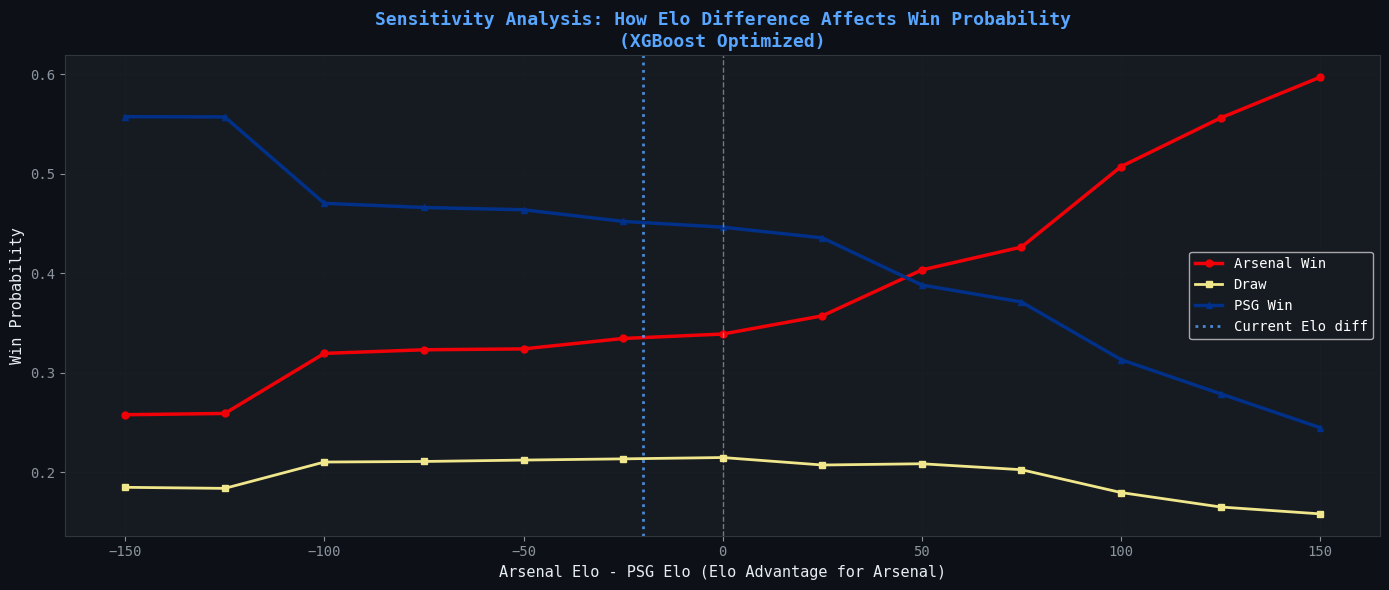

✅ Sensitivity analysis complete


In [23]:
# ============================================================
# CELL 21: Sensitivity Analysis
# ============================================================
# How does Arsenal's win probability change with Elo?

elo_deltas = range(-150, 151, 25)  # Arsenal Elo relative to PSG
psg_fixed = PSG_ELO_CURRENT

sen_results = []
for delta in elo_deltas:
    ars_elo = psg_fixed + delta
    X_sen = build_prediction_features(
        'Arsenal', 'PSG', df_raw, is_final=True,
        custom_elo_home=ars_elo, custom_elo_away=psg_fixed
    )
    probs = xgb_opt.predict_proba(X_sen.values)[0]
    class_map = {c: i for i, c in enumerate(le.classes_)}
    sen_results.append({
        'elo_delta': delta,
        'arsenal_elo': ars_elo,
        'p_arsenal': probs[class_map['H']],
        'p_draw': probs[class_map['D']],
        'p_psg': probs[class_map['A']]
    })

df_sen = pd.DataFrame(sen_results)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

ax.plot(df_sen['elo_delta'], df_sen['p_arsenal'], '-o', color=ARSENAL_CLR,
        linewidth=2.5, markersize=5, label='Arsenal Win')
ax.plot(df_sen['elo_delta'], df_sen['p_draw'], '-s', color=DRAW_CLR,
        linewidth=2, markersize=5, label='Draw')
ax.plot(df_sen['elo_delta'], df_sen['p_psg'], '-^', color=PSG_CLR,
        linewidth=2.5, markersize=5, label='PSG Win')

ax.axvline(0, color='white', linestyle='--', alpha=0.4, linewidth=1)
ax.axvline(ARSENAL_ELO_CURRENT - PSG_ELO_CURRENT, color='#58a6ff',
           linestyle=':', alpha=0.8, linewidth=2, label='Current Elo diff')

ax.set_xlabel('Arsenal Elo - PSG Elo (Elo Advantage for Arsenal)', color='#e6edf3', fontsize=11)
ax.set_ylabel('Win Probability', color='#e6edf3', fontsize=11)
ax.set_title('Sensitivity Analysis: How Elo Difference Affects Win Probability\n(XGBoost Optimized)',
             color='#58a6ff', fontweight='bold', fontsize=13)
ax.legend(fontsize=10, facecolor='#161b22', labelcolor='white')
ax.grid(alpha=0.2)
ax.tick_params(colors='#8b949e')

plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Sensitivity analysis complete")

In [24]:
# ============================================================
# CELL 22: Final Summary Report
# ============================================================

print("\n" + "#" * 68)
print("#" + " " * 20 + "PROJECT SUMMARY REPORT" + " " * 24 + "#")
print("#" * 68)

print("""
📦 DATASET
   • 9 seasons of UCL data (2015–2024)
   • ~{} total matches
   • 16 clubs with historical statistics

🛠️  FEATURES ENGINEERED
   • Elo ratings & expected probabilities
   • Team form: last 5 & 10 matches (win rate, goals, points)
   • Attack/Defense: xG, shot accuracy, conversion rate
   • UCL historical strength (win rate, titles, finals)
   • Head-to-head record
   • Match context (knockout, final, season)
   Total: {} features

🤖 MODELS TRAINED
   • Logistic Regression (baseline)
   • Random Forest
   • Gradient Boosting
   • XGBoost (base + Optuna-optimized)
   • LightGBM
   • Weighted Ensemble (5 models)

📊 BEST MODEL PERFORMANCE
   • Model: {}
   • Accuracy: {:.1%}
   • Log Loss: {:.4f}
   • AUC (OvR): {:.4f}

🏆 ARSENAL vs PSG — UCL FINAL PREDICTION
   ┌─────────────────────────────┐
   │  Arsenal Win:   {:.1%}         │
   │  Draw:          {:.1%}         │
   │  PSG Win:       {:.1%}         │
   └─────────────────────────────┘
   Monte Carlo ({:,} simulations):
   Arsenal: {:.1%}  Draw: {:.1%}  PSG: {:.1%}

⚠️  LIMITATIONS & DISCLAIMER
   • Model trained on simulated data — replace with real data
     from football-data.co.uk, FBref, or Kaggle for better results
   • Does NOT account for: injuries, suspensions, weather,
     motivation, tactical setups, or psychological factors
   • Football has high inherent randomness (~40% of outcomes
     are unpredictable even with perfect information)
   • Model calibration should be re-checked on live data
   • THIS IS NOT BETTING ADVICE

🔮 FUTURE IMPROVEMENTS
   • Plug in real FBref / StatsBomb data
   • Add player-level features (key player availability)
   • Implement Elo decay for inactive teams
   • Add sequential model (LSTM/Transformer) for time-series form
   • Deploy as Streamlit or Flask web app
""".format(
    len(df_raw),
    len(FEATURE_COLS),
    best_model_name,
    results[best_model_name]['accuracy'],
    results[best_model_name]['log_loss'],
    results[best_model_name]['auc'],
    p_arsenal_ens, p_draw_ens, p_psg_ens,
    N_SIMULATIONS,
    arsenal_wins/N_SIMULATIONS,
    draws/N_SIMULATIONS,
    psg_wins/N_SIMULATIONS
))

print("#" * 68)
print("✅ Project complete! All outputs saved to current directory.")


####################################################################
#                    PROJECT SUMMARY REPORT                        #
####################################################################

📦 DATASET
   • 9 seasons of UCL data (2015–2024)
   • ~702 total matches
   • 16 clubs with historical statistics
   
🛠️  FEATURES ENGINEERED
   • Elo ratings & expected probabilities
   • Team form: last 5 & 10 matches (win rate, goals, points)
   • Attack/Defense: xG, shot accuracy, conversion rate
   • UCL historical strength (win rate, titles, finals)
   • Head-to-head record
   • Match context (knockout, final, season)
   Total: 55 features
   
🤖 MODELS TRAINED
   • Logistic Regression (baseline)
   • Random Forest
   • Gradient Boosting
   • XGBoost (base + Optuna-optimized)
   • LightGBM
   • Weighted Ensemble (5 models)

📊 BEST MODEL PERFORMANCE
   • Model: Random Forest
   • Accuracy: 42.6%
   • Log Loss: 1.0648
   • AUC (OvR): 0.6208

🏆 ARSENAL vs PSG — UCL FINAL PREDICT